# The objective is to investigate whether a complex deep learning model(LSTM) provides better predictive performance than a traditional statistical model (LinearRegression) when forecasting daily stock returns. The study also evaluates whether increased model complexity leads to improvedprediction accuracy or simply increases the risk of overfitting.

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox,het_arch
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import ttest_rel,wilcoxon
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

df_real = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01"
)
df_real.to_csv("Raw_AAPL.csv")

df_real = df_real.reset_index()
df_real.columns = [col[0] for col in df_real.columns]
print(df_real.columns)

df_real["Date"] = pd.to_datetime(df_real["Date"])
cols_real = ["Open","High","Low","Close","Volume"]
for col in cols_real:
    df_real[col] = pd.to_numeric(df_real[col], errors="coerce")
df_real = df_real.iloc[2:].reset_index(drop=True)
#print(df_real.info())
#print(df_real.describe())
print(df_real.isnull().sum())
print("Duplicate dates:",df_real["Date"].duplicated().sum())
print((df_real[["Open","High","Low","Close"]] < 0).sum())
df_real.to_csv("Cleaned_AAPL.csv",index=False)

2026-08-28 19:45:44.224976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787946344.486225      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787946344.558266      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787946345.138321      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787946345.138364      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787946345.138367      58 computation_placer.cc:177] computation placer alr

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Duplicate dates: 0
Open     0
High     0
Low      0
Close    0
dtype: int64


# **Data Cleaning** 



# Predicting returns instead of prices because prices continuously increase over time because of inflation and company growth whereas returns are more stationary, less affected by long-term trends and easier for statistical models.

In [2]:
df_real["Return"] = df_real["Close"].pct_change()
df_real["Lag1"] = df_real["Return"].shift(1)
df_real["Lag2"] = df_real["Return"].shift(2)
df_real["Lag5"] = df_real["Return"].shift(5)
df_real["Target"] = df_real["Return"].shift(-1)
df_real["MA5"] = df_real["Close"].rolling(5).mean()
df_real["MA20"] = df_real["Close"].rolling(20).mean()
df_real["Volatility20"] = df_real["Return"].rolling(20).std()
df_real["VolumeChange"] = df_real["Volume"].pct_change()
print(df_real.head())
df_real = df_real.dropna().reset_index(drop=True)

        Date      Close       High        Low       Open     Volume    Return  \
0 2015-01-06  23.493011  23.751686  23.132634  23.554916  263188400       NaN   
1 2015-01-07  23.822432  23.921921  23.590287  23.700831  160423600  0.014022   
2 2015-01-08  24.737749  24.795233  24.032472  24.149651  237458000  0.038423   
3 2015-01-09  24.764280  25.038431  24.366318  24.910199  214798000  0.001072   
4 2015-01-12  24.154072  24.901355  24.054582  24.894723  198603200 -0.024641   

       Lag1      Lag2  Lag5    Target        MA5  MA20  Volatility20  \
0       NaN       NaN   NaN  0.014022        NaN   NaN           NaN   
1       NaN       NaN   NaN  0.038423        NaN   NaN           NaN   
2  0.014022       NaN   NaN  0.001072        NaN   NaN           NaN   
3  0.038423  0.014022   NaN -0.024641        NaN   NaN           NaN   
4  0.001072  0.038423   NaN  0.008879  24.194309   NaN           NaN   

   VolumeChange  
0           NaN  
1     -0.390461  
2      0.480194  
3     -0

# For your Linear Regression model, these engineered features are essential because the model cannot automatically remember previous observations. The lag variables and moving averages provide the historical information it needs.

# For the LSTM model, the network already processes sequences of past observations, so lag features are not strictly necessary. However, moving averages and other technical indicators can still provide useful summary information and sometimes improve performance.

# **Exploratory Data Analysis (EDA)**

Observations : 2493
Start Date : 2015-02-04 00:00:00
End Date : 2024-12-30 00:00:00
Missing Values : 0
Duplicate Dates : 0


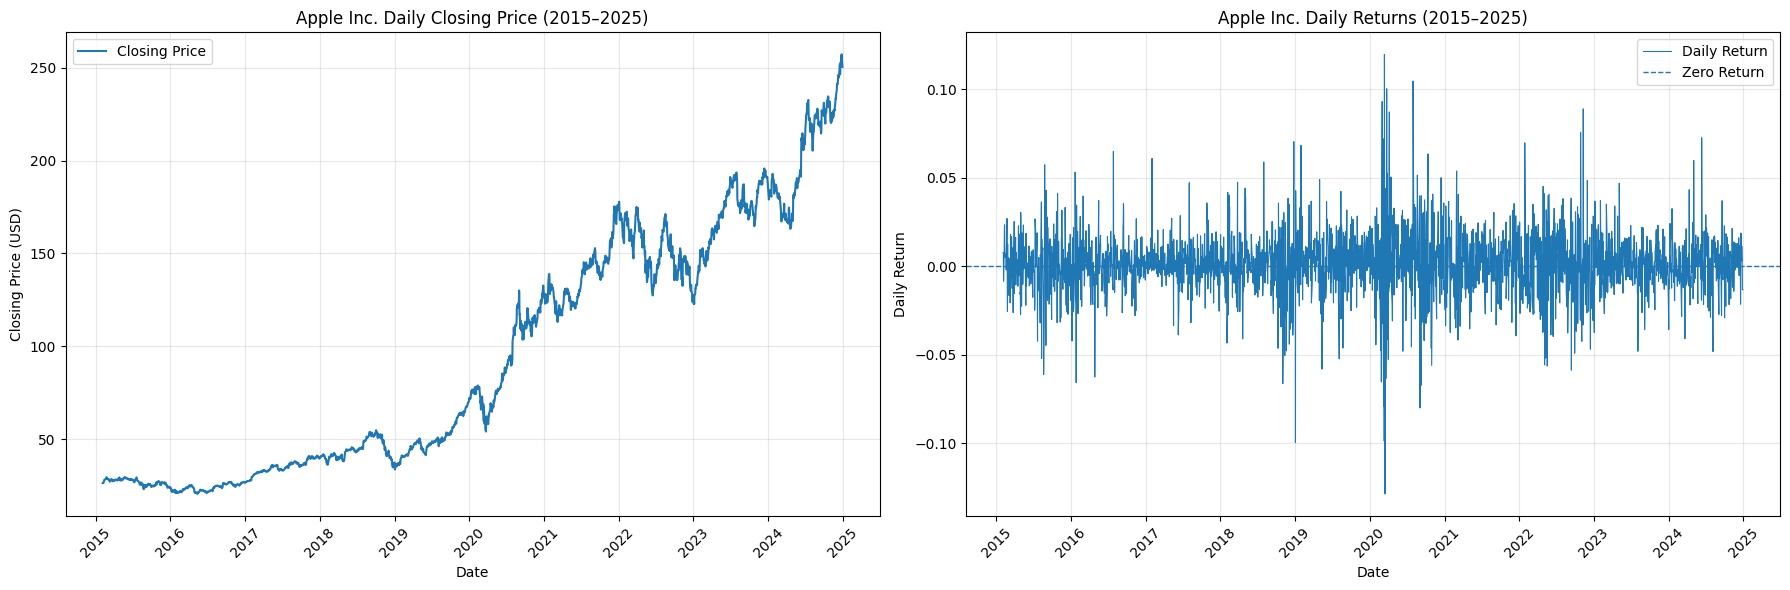

Mean : 0.001065
Median : 0.000989
Standard Deviation : 0.017885
Minimum : -0.128647
Maximum : 0.119808
Skewness : -0.011087
Excess Kurtosis : 5.405614
Kurtosis : 8.405614


/tmp/ipykernel_58/2918573823.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(returns_real,vert=True,labels=["Returns"])


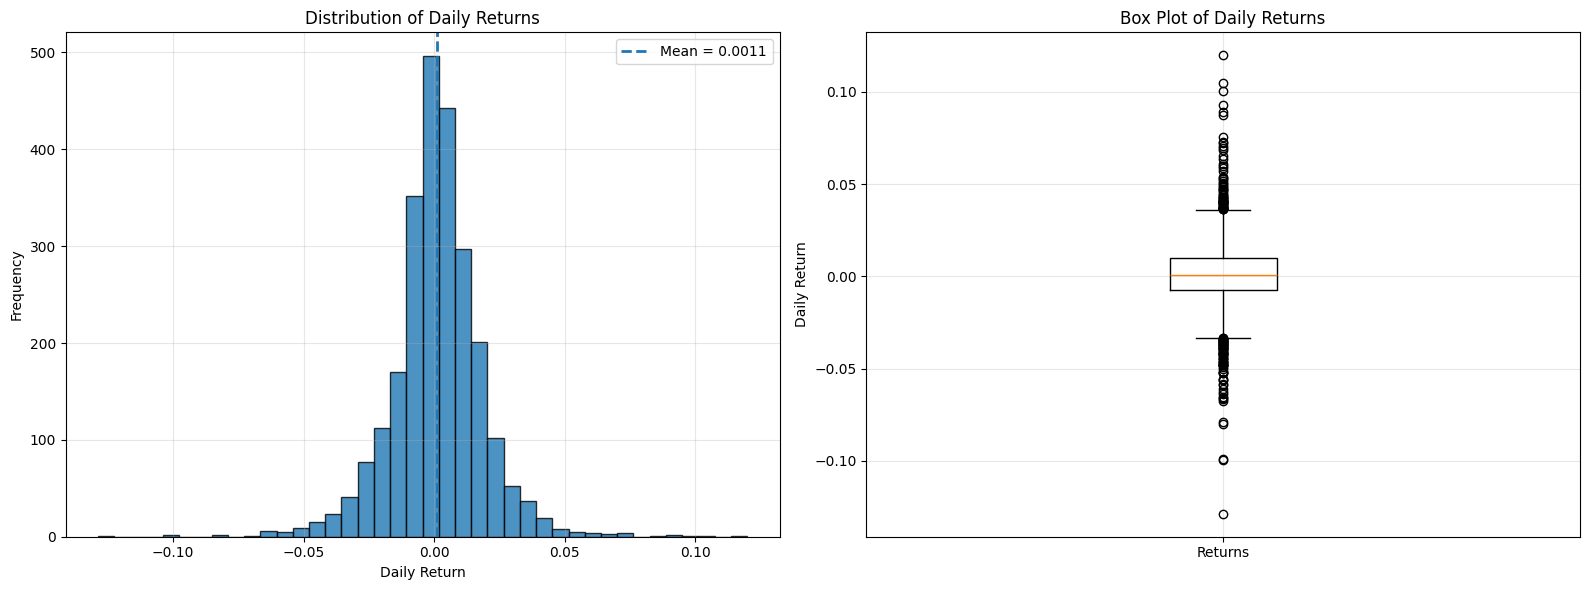

Jarque-Bera Statistic : 3020.495937
Jarque-Bera p-value : 0.0
Conclusion: Reject H0. Returns are not normally distributed.


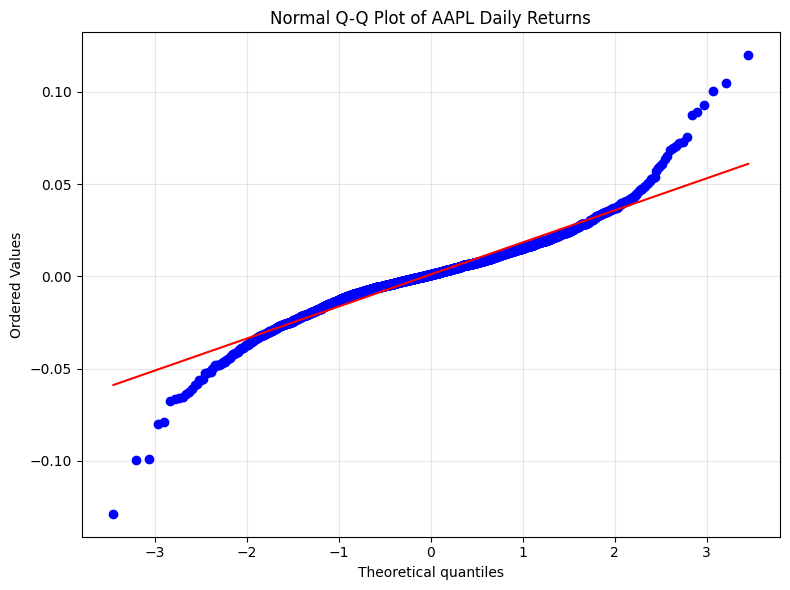

ADF Statistic : -15.661372
ADF p-value : 0.0
1% : -3.432985
5% : -2.862704
10% : -2.56739
Conclusion: Reject H0. Returns are stationary.
KPSS Statistic : 0.09684
KPSS p-value : 0.1
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739
Conclusion: Fail to reject H0. Stationarity is not rejected.


/tmp/ipykernel_58/2918573823.py:83: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_real=kpss(returns_real,regression="c",nlags="auto")


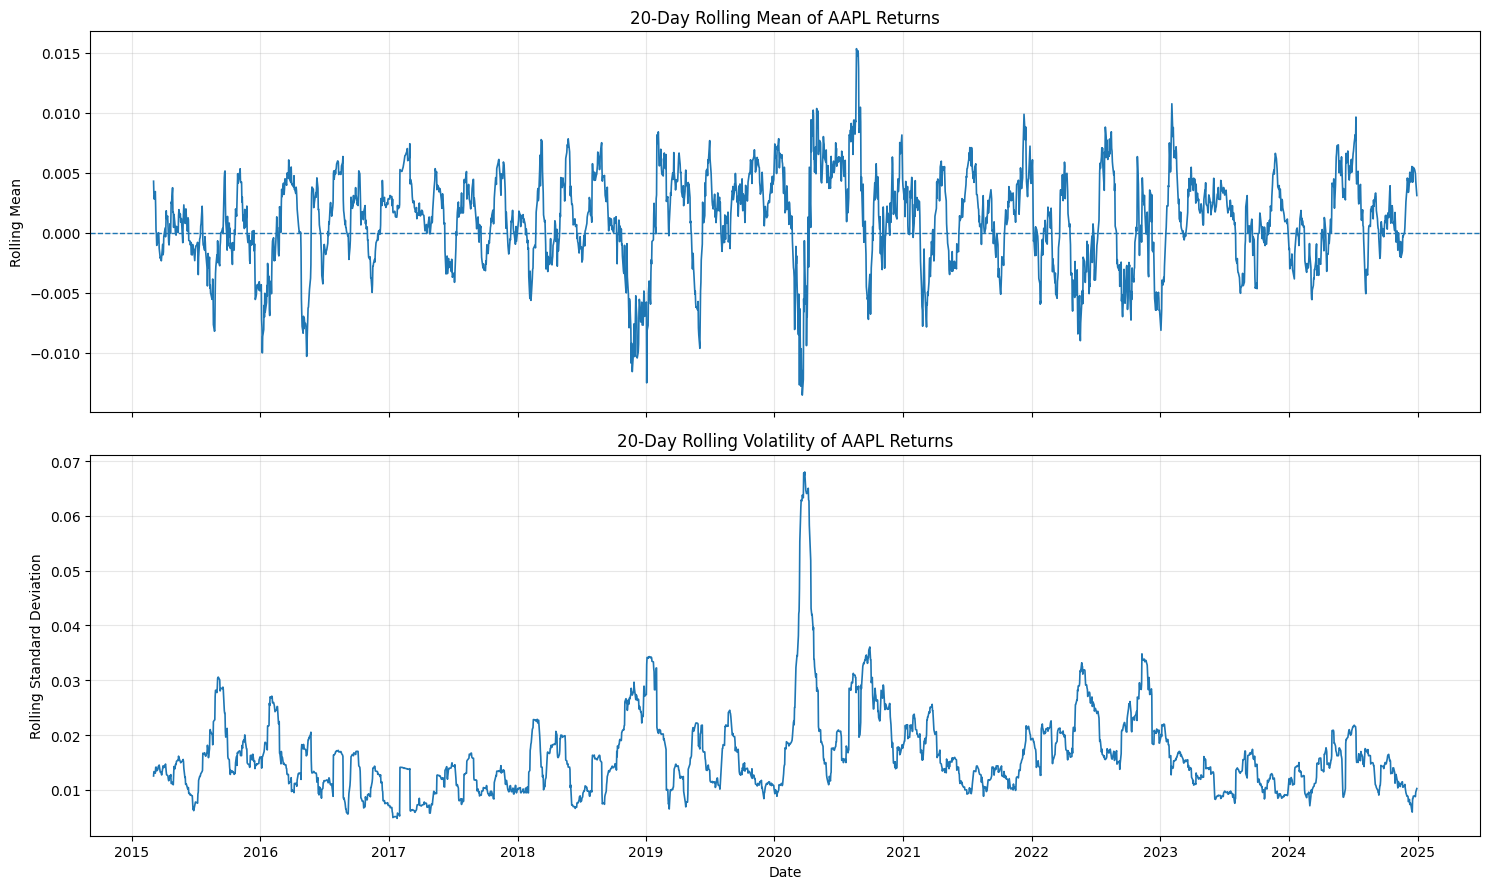

Average Rolling Mean : 0.001042
Average Rolling Volatility : 0.01625


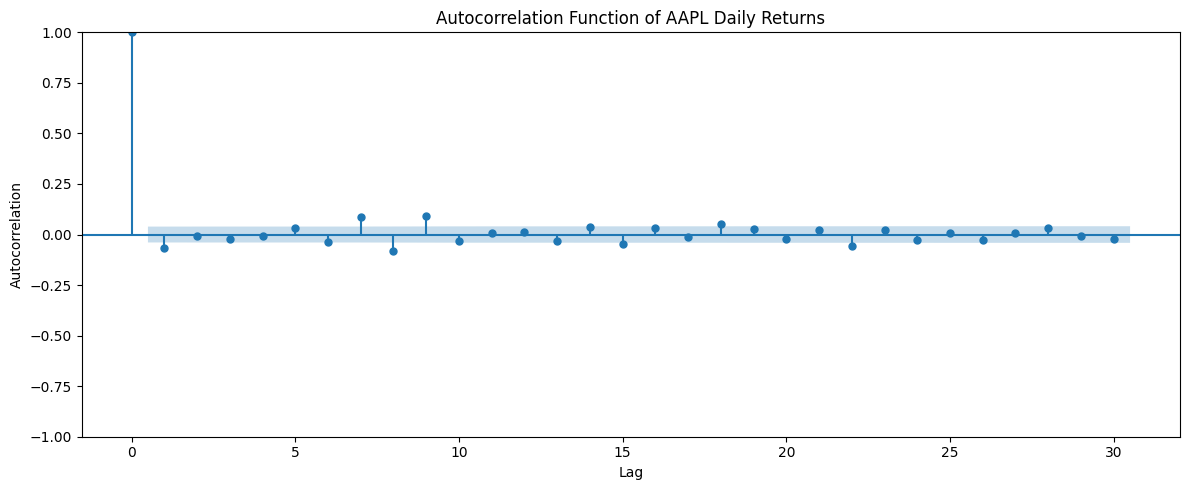

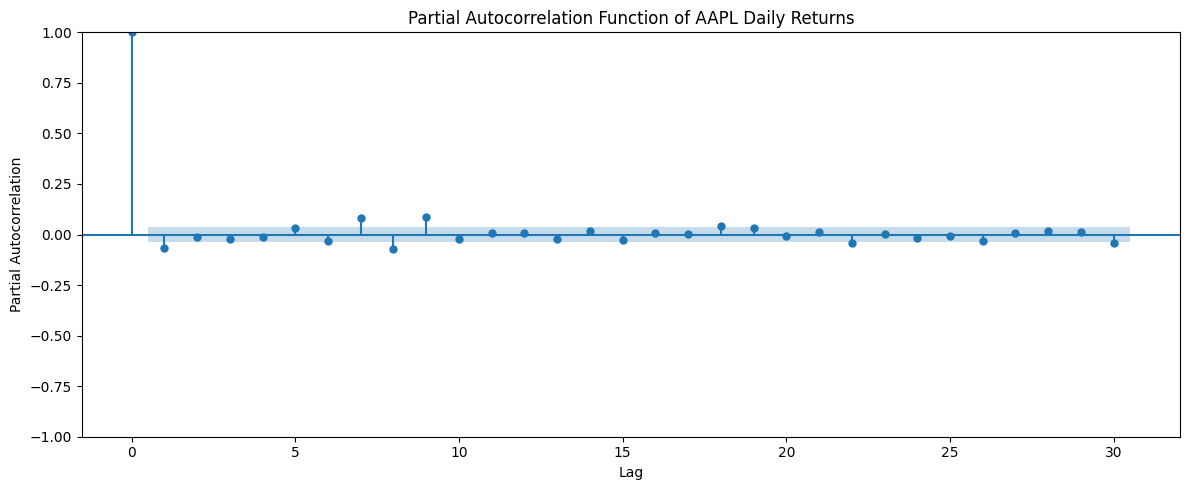

       lb_stat     lb_pvalue
5    15.504543  8.410636e-03
10   77.045090  1.900038e-12
20  102.855549  3.870012e-13


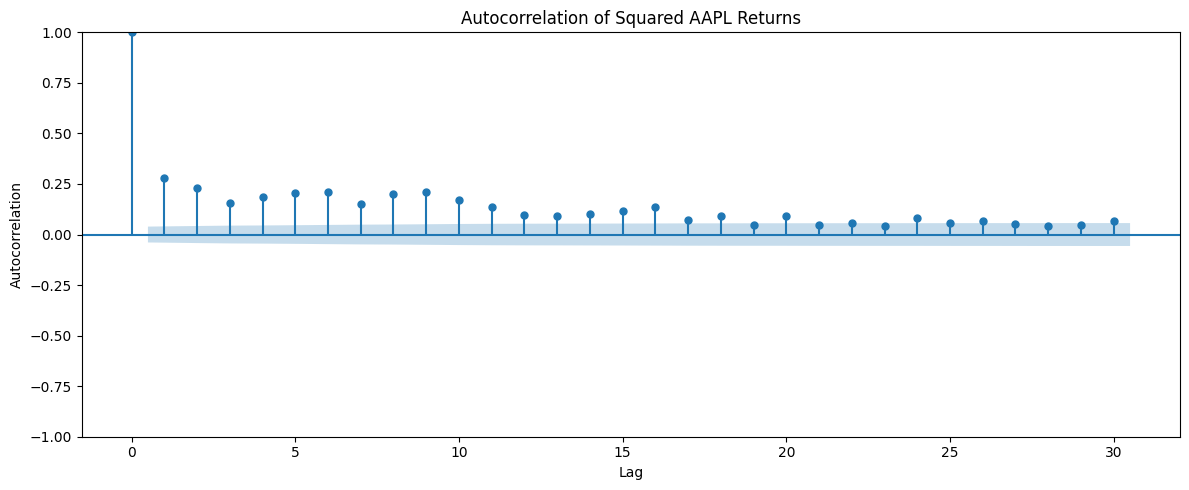

        lb_stat      lb_pvalue
5    578.409060  9.343090e-123
10  1029.451191  8.452545e-215
20  1288.536966  8.427365e-261
ARCH LM Statistic : 401.534062
ARCH LM p-value : 0.0
Conclusion: Significant ARCH effects detected.


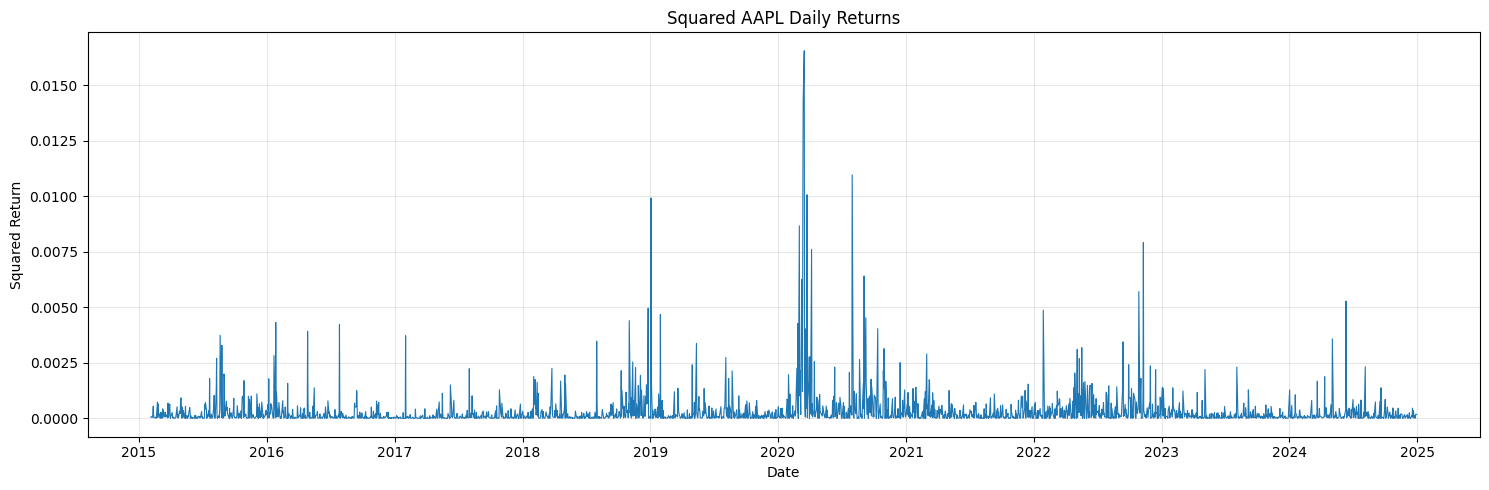

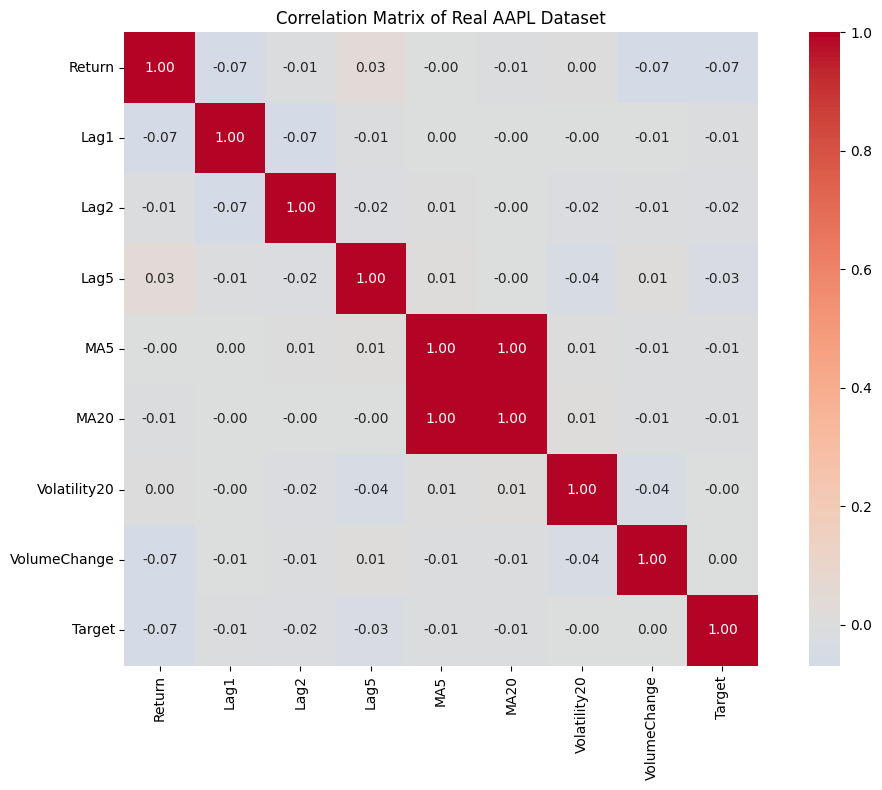

                Return      Lag1      Lag2      Lag5       MA5      MA20  \
Return        1.000000 -0.068172 -0.005921  0.032392 -0.002817 -0.006208   
Lag1         -0.068172  1.000000 -0.068454 -0.007792  0.002364 -0.004238   
Lag2         -0.005921 -0.068454  1.000000 -0.020763  0.007299 -0.002665   
Lag5          0.032392 -0.007792 -0.020763  1.000000  0.013557 -0.001826   
MA5          -0.002817  0.002364  0.007299  0.013557  1.000000  0.998506   
MA20         -0.006208 -0.004238 -0.002665 -0.001826  0.998506  1.000000   
Volatility20  0.003637 -0.004383 -0.018671 -0.037103  0.005627  0.014228   
VolumeChange -0.067893 -0.005554 -0.012609  0.011791 -0.010967 -0.011301   
Target       -0.068009 -0.005870 -0.021690 -0.034810 -0.007717 -0.007743   

              Volatility20  VolumeChange    Target  
Return            0.003637     -0.067893 -0.068009  
Lag1             -0.004383     -0.005554 -0.005870  
Lag2             -0.018671     -0.012609 -0.021690  
Lag5             -0.037103 

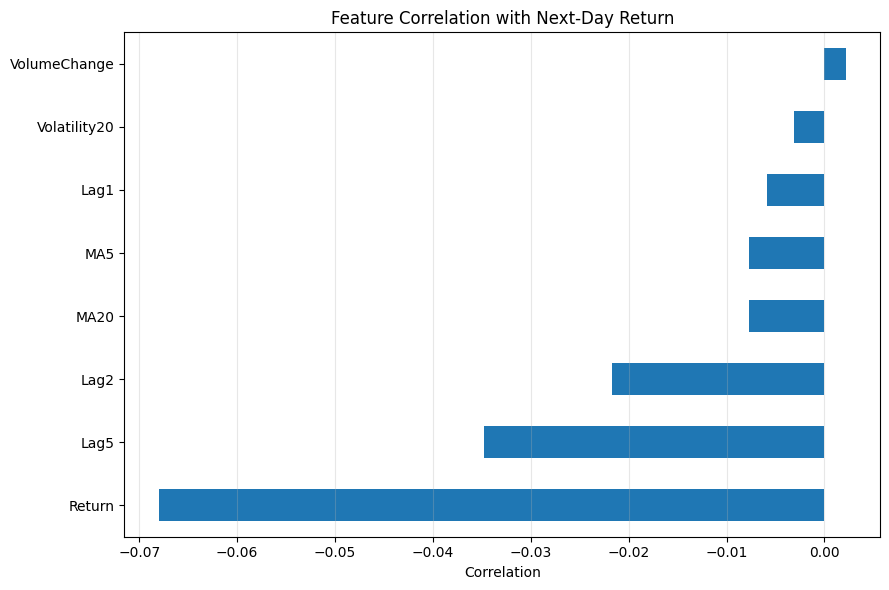

Observations : 2493
Return Mean : 0.001065
Return Std : 0.017885
Skewness : -0.011087
Excess Kurtosis : 5.405614
ADF p-value : 0.0
KPSS p-value : 0.1
ARCH p-value : 0.0


In [3]:
returns_real=df_real["Return"].dropna()

print("Observations :",len(df_real))
print("Start Date :",df_real["Date"].min())
print("End Date :",df_real["Date"].max())
print("Missing Values :",df_real.isnull().sum().sum())
print("Duplicate Dates :",df_real["Date"].duplicated().sum())

fig,ax=plt.subplots(1,2,figsize=(18,6))
ax[0].plot(df_real["Date"],df_real["Close"],linewidth=1.5,label="Closing Price")
ax[0].set_title("Apple Inc. Daily Closing Price (2015–2025)")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Closing Price (USD)")
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[0].tick_params(axis="x",rotation=45)

ax[1].plot(df_real["Date"],df_real["Return"],linewidth=0.8,label="Daily Return")
ax[1].axhline(0,linestyle="--",linewidth=1,label="Zero Return")
ax[1].set_title("Apple Inc. Daily Returns (2015–2025)")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Daily Return")
ax[1].grid(alpha=0.3)
ax[1].legend()
ax[1].tick_params(axis="x",rotation=45)
plt.tight_layout()
plt.show()

print("Mean :",round(returns_real.mean(),6))
print("Median :",round(returns_real.median(),6))
print("Standard Deviation :",round(returns_real.std(),6))
print("Minimum :",round(returns_real.min(),6))
print("Maximum :",round(returns_real.max(),6))
print("Skewness :",round(returns_real.skew(),6))
print("Excess Kurtosis :",round(returns_real.kurt(),6))
print("Kurtosis :",round(returns_real.kurtosis()+3,6))

fig,ax=plt.subplots(1,2,figsize=(16,6))

ax[0].hist(returns_real,bins=40,edgecolor="black",alpha=0.8)
ax[0].axvline(returns_real.mean(),linestyle="--",linewidth=2,label=f"Mean = {returns_real.mean():.4f}")
ax[0].set_title("Distribution of Daily Returns")
ax[0].set_xlabel("Daily Return")
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].boxplot(returns_real,vert=True,labels=["Returns"])
ax[1].set_title("Box Plot of Daily Returns")
ax[1].set_ylabel("Daily Return")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

jb_real=stats.jarque_bera(returns_real)
print("Jarque-Bera Statistic :",round(jb_real.statistic,6))
print("Jarque-Bera p-value :",round(jb_real.pvalue,6))

if jb_real.pvalue<0.05:
    print("Conclusion: Reject H0. Returns are not normally distributed.")
else:
    print("Conclusion: Fail to reject H0. Normality is not rejected.")
    
fig,ax=plt.subplots(figsize=(8,6))

stats.probplot(returns_real,dist="norm",plot=ax)
ax.set_title("Normal Q-Q Plot of AAPL Daily Returns")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

adf_real=adfuller(returns_real)
print("ADF Statistic :",round(adf_real[0],6))
print("ADF p-value :",round(adf_real[1],6))

for key,value in adf_real[4].items():
    print(key,":",round(value,6))
if adf_real[1]<0.05:
    print("Conclusion: Reject H0. Returns are stationary.")
else:
    print("Conclusion: Fail to reject H0. Stationarity is not established.")

kpss_real=kpss(returns_real,regression="c",nlags="auto")
print("KPSS Statistic :",round(kpss_real[0],6))
print("KPSS p-value :",round(kpss_real[1],6))

for key,value in kpss_real[3].items():
    print(key,":",value)
if kpss_real[1]<0.05:
    print("Conclusion: Reject H0. Evidence against stationarity.")
else:
    print("Conclusion: Fail to reject H0. Stationarity is not rejected.")
    
rolling_mean_real=returns_real.rolling(20).mean()
rolling_volatility_real=returns_real.rolling(20).std()

fig,ax=plt.subplots(2,1,figsize=(15,9),sharex=True)

ax[0].plot(df_real["Date"],rolling_mean_real,linewidth=1.2)
ax[0].axhline(0,linestyle="--",linewidth=1)
ax[0].set_title("20-Day Rolling Mean of AAPL Returns")
ax[0].set_ylabel("Rolling Mean")
ax[0].grid(alpha=0.3)

ax[1].plot(df_real["Date"],rolling_volatility_real,linewidth=1.2)
ax[1].set_title("20-Day Rolling Volatility of AAPL Returns")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Rolling Standard Deviation")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Rolling Mean :",round(rolling_mean_real.mean(),6))
print("Average Rolling Volatility :",round(rolling_volatility_real.mean(),6))

fig,ax=plt.subplots(figsize=(12,5))

plot_acf(returns_real,lags=30,ax=ax)
ax.set_title("Autocorrelation Function of AAPL Daily Returns")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

fig,ax=plt.subplots(figsize=(12,5))

plot_pacf(returns_real,lags=30,method="ywm",ax=ax)
ax.set_title("Partial Autocorrelation Function of AAPL Daily Returns")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()

ljungbox_real=acorr_ljungbox(returns_real,lags=[5,10,20],return_df=True)
print(ljungbox_real)

fig,ax=plt.subplots(figsize=(12,5))

plot_acf(returns_real**2,lags=30,ax=ax)
ax.set_title("Autocorrelation of Squared AAPL Returns")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

ljungbox_squared_real=acorr_ljungbox(returns_real**2,lags=[5,10,20],return_df=True)
print(ljungbox_squared_real)

arch_stat_real,arch_p_real,_,_= het_arch(returns_real,nlags=20)
print("ARCH LM Statistic :",round(arch_stat_real,6))
print("ARCH LM p-value :",round(arch_p_real,6))

if arch_p_real<0.05:
    print("Conclusion: Significant ARCH effects detected.")
else:
    print("Conclusion: No significant ARCH effects detected.")

fig,ax=plt.subplots(figsize=(15,5))

ax.plot(df_real["Date"],returns_real**2,linewidth=0.8)
ax.set_title("Squared AAPL Daily Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Squared Return")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

features_real=["Lag1","Lag2","Lag5","MA5","MA20","Volatility20","VolumeChange"]
correlation_features_real=["Return"]+features_real+["Target"]
correlation_real=df_real[correlation_features_real].corr()

plt.figure(figsize=(11,8))
sns.heatmap(correlation_real,annot=True,fmt=".2f",center=0,cmap="coolwarm",square=True)
plt.title("Correlation Matrix of Real AAPL Dataset")
plt.tight_layout()
plt.show()
print(correlation_real)

target_correlation_real=correlation_real["Target"].sort_values(ascending=False)
print(target_correlation_real)

plt.figure(figsize=(9,6))
target_correlation_real.drop("Target").sort_values().plot(kind="barh")
plt.title("Feature Correlation with Next-Day Return")
plt.xlabel("Correlation")
plt.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.show()

print("Observations :",len(df_real))
print("Return Mean :",round(returns_real.mean(),6))
print("Return Std :",round(returns_real.std(),6))
print("Skewness :",round(returns_real.skew(),6))
print("Excess Kurtosis :",round(returns_real.kurt(),6))
print("ADF p-value :",round(adf_real[1],6))
print("KPSS p-value :",round(kpss_real[1],6))
print("ARCH p-value :",round(arch_p_real,6))

# The stock price shows a strong upward long-term trend, increasing in 2015 to the beginning of 2025. There are several periods of temporary declines, particularly around 2018, 2020, and 2022, but the overall direction remains positive.
# Since the stock price is non-stationary, using the raw closing price directly for prediction can lead to misleading results. Therefore, daily returns are analysed instead.
# Daily returns fluctuate around zero, which is expected for financial returns. Most observations lie between −3% and +3%. Several large positive and negative spikes are observed, especially during 2020. Unlike stock prices, returns appear relatively stationary because they fluctuate around a constant mean.
# The box represents median return is close to zero and some daily returns exceed ±10%, reflecting rare but substantial market movements. These outliers correspond to major financial events and periods of elevated volatility.

# **Train-Test Split**


In [4]:
split_real=int(len(df_real)*0.80)
train_real=df_real.iloc[:split_real].copy()
test_real=df_real.iloc[split_real:].copy()
print("Training observations :",len(train_real))
print("Testing observations :",len(test_real))
print()
print("Training Start :",train_real["Date"].min())
print("Training End :",train_real["Date"].max())
print()
print("Testing Start :",test_real["Date"].min())
print("Testing End :",test_real["Date"].max())
features_real=["Lag1","Lag2","Lag5","MA5","MA20","Volatility20","VolumeChange"]
target_real="Target"
X_train_real=train_real[features_real]
X_test_real=test_real[features_real]
y_train_real=train_real[target_real]
y_test_real=test_real[target_real]
scaler_real=MinMaxScaler()
X_train_real_scaled=scaler_real.fit_transform(X_train_real)
X_test_real_scaled=scaler_real.transform(X_test_real)
X_train_real_scaled=pd.DataFrame(X_train_real_scaled,columns=features_real,index=X_train_real.index)
X_test_real_scaled=pd.DataFrame(X_test_real_scaled,columns=features_real,index=X_test_real.index)
train_real.to_csv("Train_Data_Real.csv",index=False)
test_real.to_csv("Test_Data_Real.csv",index=False)
X_train_real_scaled.to_csv("X_train_Real_scaled.csv",index=False)
X_test_real_scaled.to_csv("X_test_Real_scaled.csv",index=False)
y_train_real.to_csv("y_train_Real.csv",index=False)
y_test_real.to_csv("y_test_Real.csv",index=False)

Training observations : 1994
Testing observations : 499

Training Start : 2015-02-04 00:00:00
Training End : 2023-01-04 00:00:00

Testing Start : 2023-01-05 00:00:00
Testing End : 2024-12-30 00:00:00


# The dataset is divided into 80% training data and 20% testing data using a chronological split, resulting in 1,994 training observations and 499 testing observations. The training set covers the period from 4 February 2015 to 4 January 2023, while the testing set spans 5 January 2023 to 30 December 2024. 
# Using 80% of the observations for training provides enough examples of different market conditions, including bull markets, bearish periods, and high-volatility events. Reserving the remaining 20% of the data for testing allows the models to be evaluated on unseen observations.

# **Linear Regression Model**

# Linear Regression was selected because it is simple, highly interpretable, provides coefficient estimates, and it acts as the baseline model.

In [5]:
X_train_real=pd.read_csv("X_train_Real_scaled.csv")
X_test_real=pd.read_csv("X_test_Real_scaled.csv")
y_train_real=pd.read_csv("y_train_Real.csv").squeeze()
y_test_real=pd.read_csv("y_test_Real.csv").squeeze()

lr_real=LinearRegression()
lr_real.fit(X_train_real,y_train_real)

train_pred_real=lr_real.predict(X_train_real)
test_pred_real=lr_real.predict(X_test_real)

def evaluate_model_real(actual,predicted):
    mse=mean_squared_error(actual,predicted)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(actual,predicted)
    r2=r2_score(actual,predicted)
    
    return mse,rmse,mae,r2
    
train_metrics_real=evaluate_model_real(y_train_real,train_pred_real)
test_metrics_real=evaluate_model_real(y_test_real,test_pred_real)

results_real=pd.DataFrame({
    "Dataset":["Training","Testing"],
    "MSE":[train_metrics_real[0],test_metrics_real[0]],
    "RMSE":[train_metrics_real[1],test_metrics_real[1]],
    "MAE":[train_metrics_real[2],test_metrics_real[2]],
    "R2":[train_metrics_real[3],test_metrics_real[3]]
})

print(results_real)
results_real.to_csv("LinearRegression_Real_Results.csv",index=False)

    Dataset       MSE      RMSE       MAE        R2
0  Training  0.000353  0.018795  0.013124  0.003273
1   Testing  0.000184  0.013548  0.010102 -0.014770


In [6]:
naive_pred_real=np.full(
    len(y_test_real),
    y_train_real.mean()
)

naive_metrics_real=evaluate_model_real(
    y_test_real,
    naive_pred_real
)

print("Naive Mean-Return Baseline")
print("MSE :",round(naive_metrics_real[0],6))
print("RMSE :",round(naive_metrics_real[1],6))
print("MAE :",round(naive_metrics_real[2],6))
print("R2 :",round(naive_metrics_real[3],6))

Naive Mean-Return Baseline
MSE : 0.000181
RMSE : 0.01346
MAE : 0.010005
R2 : -0.00171


# The testing MSE is slightly lower than the training MSE. This indicates that the model's prediction error on unseen data is not larger than on the training data, suggesting no evidence of overfitting. The testing RMSE is also lower than the training RMSE, again indicating that the model generalises consistently to unseen data.
# A negative test R² indicates that the model performs slightly worse than simply predicting the mean return for every observation. This is not unusual for daily stock return prediction. Daily returns are close to random and are influenced by many unpredictable factors such as news, investor sentiment, macroeconomic events, and company announcements.


# **Detect Overfitting**

Overfitting Gap (MSE): -0.0001697280191976721
        Feature  Coefficient
0          Lag1    -0.002523
1          Lag2    -0.007224
2          Lag5    -0.012228
3           MA5     0.027333
4          MA20    -0.027897
5  Volatility20     0.000034
6  VolumeChange     0.000780


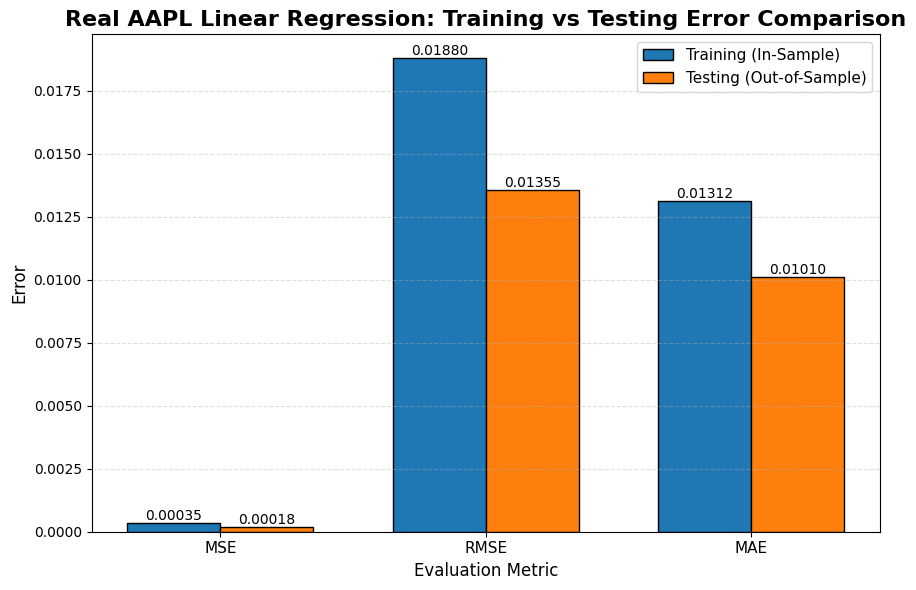

     Actual  Predicted  Residual
0  0.036794   0.001716  0.035078
1  0.004089  -0.002218  0.006307
2  0.004456  -0.000762  0.005219
3  0.021112   0.000477  0.020635
4 -0.000599  -0.000533 -0.000067


In [7]:
gap_real=test_metrics_real[0]-train_metrics_real[0]
print("Overfitting Gap (MSE):",gap_real)

coef_real=pd.DataFrame({
    "Feature":X_train_real.columns,
    "Coefficient":lr_real.coef_
})
print(coef_real)

metrics_real=["MSE","RMSE","MAE"]

train_errors_real=[train_metrics_real[0],train_metrics_real[1],train_metrics_real[2]]
test_errors_real=[test_metrics_real[0],test_metrics_real[1],test_metrics_real[2]]

x_real = np.arange(len(metrics_real))
width_real=0.35
fig,ax=plt.subplots(figsize=(9,6))

bars1=ax.bar(x_real-width_real/2,train_errors_real,width_real,label="Training (In-Sample)",edgecolor="black")
bars2=ax.bar(x_real+width_real/2,test_errors_real,width_real,label="Testing (Out-of-Sample)",edgecolor="black")

for bar in bars1:
    height=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2,height,f"{height:.5f}",ha="center",va="bottom",fontsize=10)
    
for bar in bars2:
    height=bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2,height,f"{height:.5f}",ha="center",va="bottom",fontsize=10)
    
ax.set_title("Real AAPL Linear Regression: Training vs Testing Error Comparison",fontsize=16,fontweight="bold")
ax.set_xlabel("Evaluation Metric",fontsize=12)
ax.set_ylabel("Error",fontsize=12)
ax.set_xticks(x_real)
ax.set_xticklabels(metrics_real,fontsize=11)
ax.grid(axis="y",linestyle="--",alpha=0.4)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

prediction_lr_real=pd.DataFrame({
    "Actual":y_test_real,
    "Predicted":test_pred_real,
    "Residual":y_test_real-test_pred_real
})

prediction_lr_real.to_csv(
    "LinearRegression_Real_Predictions.csv",
    index=False
)

print(prediction_lr_real.head())



Linear Regression Directional Accuracy : 49.9 %
Naive Baseline Directional Accuracy : 56.31 %


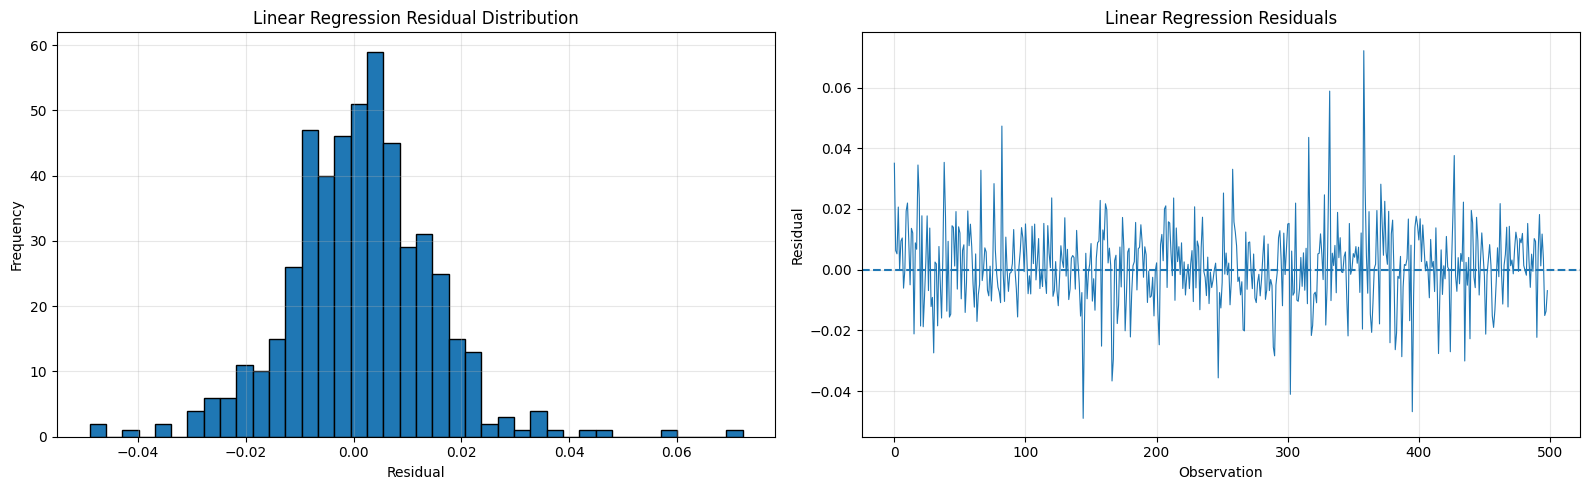

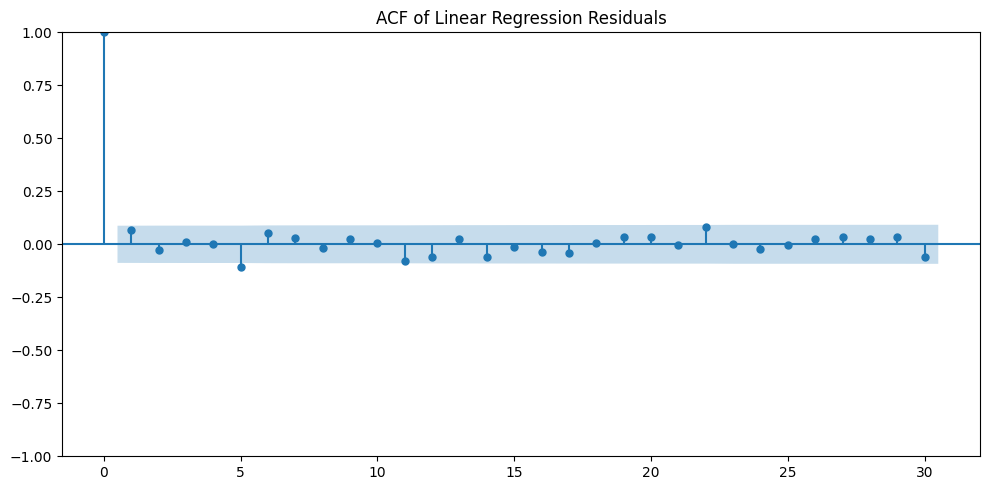

      lb_stat  lb_pvalue
5    8.302509   0.140333
10  10.726184   0.379245
20  20.632276   0.419053


In [8]:
def directional_accuracy(actual,predicted):
    return np.mean(np.sign(actual)==np.sign(predicted))

direction_lr_real=directional_accuracy(
    y_test_real,
    test_pred_real
)

direction_naive_real=directional_accuracy(
    y_test_real,
    naive_pred_real
)

print("Linear Regression Directional Accuracy :",
      round(direction_lr_real*100,2),"%")

print("Naive Baseline Directional Accuracy :",
      round(direction_naive_real*100,2),"%")

residual_lr_real=y_test_real.values-test_pred_real

fig,ax=plt.subplots(1,2,figsize=(16,5))

ax[0].hist(
    residual_lr_real,
    bins=40,
    edgecolor="black"
)
ax[0].set_title("Linear Regression Residual Distribution")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha=0.3)

ax[1].plot(
    residual_lr_real,
    linewidth=0.8
)
ax[1].axhline(0,linestyle="--")
ax[1].set_title("Linear Regression Residuals")
ax[1].set_xlabel("Observation")
ax[1].set_ylabel("Residual")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig,ax=plt.subplots(figsize=(10,5))

plot_acf(
    residual_lr_real,
    lags=30,
    ax=ax
)

ax.set_title("ACF of Linear Regression Residuals")
plt.tight_layout()
plt.show()

ljungbox_residual_lr_real=acorr_ljungbox(
    residual_lr_real,
    lags=[5,10,20],
    return_df=True
)

print(ljungbox_residual_lr_real)

# Overfitting Gap = Testing MSE − Training MSE
# The negative value means the testing error is slightly lower than the training error. This indicates that the Linear Regression model does not exhibit overfitting on this train/test split.

# **LSTM Model**

In [9]:
time_steps_real= 20

def create_sequences_real(X,y,time_steps):
    X_seq_real = []
    y_seq_real = []
    for i in range(len(X)-time_steps):
        X_seq_real.append(X.iloc[i:i+time_steps].values)
        y_seq_real.append(y.iloc[i+time_steps])
    return np.array(X_seq_real),np.array(y_seq_real)
    
X_train_lstm_real,y_train_lstm_real=create_sequences_real(X_train_real,y_train_real,time_steps_real)
X_test_lstm_real,y_test_lstm_real=create_sequences_real(X_test_real,y_test_real,time_steps_real)

print("Training Shape :",X_train_lstm_real.shape)
print("Testing Shape :",X_test_lstm_real.shape)

lstm_real= Sequential()
lstm_real.add(LSTM(units=64,return_sequences=True,input_shape=(time_steps_real,X_train_lstm_real.shape[2])))
lstm_real.add(Dropout(0.2))
lstm_real.add(LSTM(units=32))
lstm_real.add(Dropout(0.2))
lstm_real.add(Dense(16,activation="relu"))
lstm_real.add(Dense(1))
lstm_real.compile(optimizer="adam",loss="mse")
lstm_real.summary()

early_stop_real=EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

history_real=lstm_real.fit(
    X_train_lstm_real,
    y_train_lstm_real,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_real],
    verbose=1
)

train_pred_lstm_real = lstm_real.predict(X_train_lstm_real).flatten()
test_pred_lstm_real=lstm_real.predict(X_test_lstm_real).flatten()

print("Training Predictions Shape :",train_pred_lstm_real.shape)
print("Testing Predictions Shape :",test_pred_lstm_real.shape)

def evaluate_lstm_real(actual,predicted):
    mse=mean_squared_error(actual,predicted)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(actual,predicted)
    r2=r2_score(actual,predicted)
    
    return mse,rmse,mae,r2
    
train_metrics_lstm_real=evaluate_lstm_real(y_train_lstm_real,train_pred_lstm_real)
test_metrics_lstm_real=evaluate_lstm_real(y_test_lstm_real,test_pred_lstm_real)

results_lstm_real=pd.DataFrame({
    "Dataset":["Training","Testing"],
    "MSE":[train_metrics_lstm_real[0],test_metrics_lstm_real[0]],
    "RMSE":[train_metrics_lstm_real[1],test_metrics_lstm_real[1]],
    "MAE":[train_metrics_lstm_real[2],test_metrics_lstm_real[2]],
    "R2":[train_metrics_lstm_real[3],test_metrics_lstm_real[3]]
})
print(results_lstm_real)
results_lstm_real.to_csv("LSTM_Real_Results.csv",index=False)

Training Shape : (1974, 20, 7)
Testing Shape : (479, 20, 7)


2026-08-28 19:46:05.659862: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 4.8554e-04 - val_loss: 4.0336e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5420e-04 - val_loss: 4.0095e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5065e-04 - val_loss: 3.9493e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5563e-04 - val_loss: 3.9630e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5487e-04 - val_loss: 3.9685e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.4894e-04 - val_loss: 3.9678e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5176e-04 - val_loss: 3.9742e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5016e-04 - val_loss: 3.9873e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5245e-04 - val_loss: 3.9493e-04
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.4930e-04 - val_loss: 4.0041e-04
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss

# The LSTM network consisted of two stacked LSTM layers containing 64 and 32 units, respectively, followed by two fully connected (Dense) layers with 16 and 1 neurons. The first LSTM layer processed sequences of the previous 20 trading days to learn temporal dependencies within the stock return series. Dropout layers were inserted after each LSTM layer to reduce overfitting by randomly deactivating a proportion of neurons during training. The Dense layer with 16 neurons combined the extracted temporal features, while the final Dense layer with a single neuron generated the predicted next-day stock return. The network contained 31,393 trainable parameters, all of which were optimised during training.
# The LSTM model achieved similar predictive performance to the Linear Regression model on both the training and testing datasets. The testing MSE (0.000178), RMSE (0.013340), and MAE (0.009922) were close to those obtained using Linear Regression, while the testing R² (-0.005550) remained slightly negative. The testing errors were marginally lower than the training errors, indicating no evidence of overfitting. However, the LSTM failed to provide a meaningful improvement over the simpler Linear Regression model. This suggests that the additional complexity of the deep learning architecture was not able to capture useful predictive patterns in the daily stock return data.


# **Overfitting Detection**

In [10]:
gap_lstm_real = test_metrics_lstm_real[0]-train_metrics_lstm_real[0]
print("\nOverfitting Gap :",gap_lstm_real)

prediction_lstm_real=pd.DataFrame({
    "Actual":y_test_lstm_real,
    "Predicted":test_pred_lstm_real,
    "Residual":y_test_lstm_real-test_pred_lstm_real
})

prediction_lstm_real.to_csv("LSTM_Real_Predictions.csv",index=False)
print(prediction_lstm_real.head())

loss_history_real=pd.DataFrame({
    "Epoch":range(1,len(history_real.history["loss"])+1),
    "Training Loss":history_real.history["loss"],
    "Validation Loss":history_real.history["val_loss"]
})

loss_history_real.to_csv("LSTM_Real_Loss.csv",index=False)

direction_lstm_real=directional_accuracy(
    y_test_lstm_real,
    test_pred_lstm_real
)

print(
    "LSTM Directional Accuracy :",
    round(direction_lstm_real*100,2),
    "%"
)


Overfitting Gap : -0.0001792841212314387
     Actual  Predicted  Residual
0 -0.017929   0.001030 -0.018959
1  0.019245   0.000989  0.018255
2 -0.017653   0.000954 -0.018607
3 -0.006912   0.000932 -0.007843
4  0.002456   0.000950  0.001507
LSTM Directional Accuracy : 55.32 %


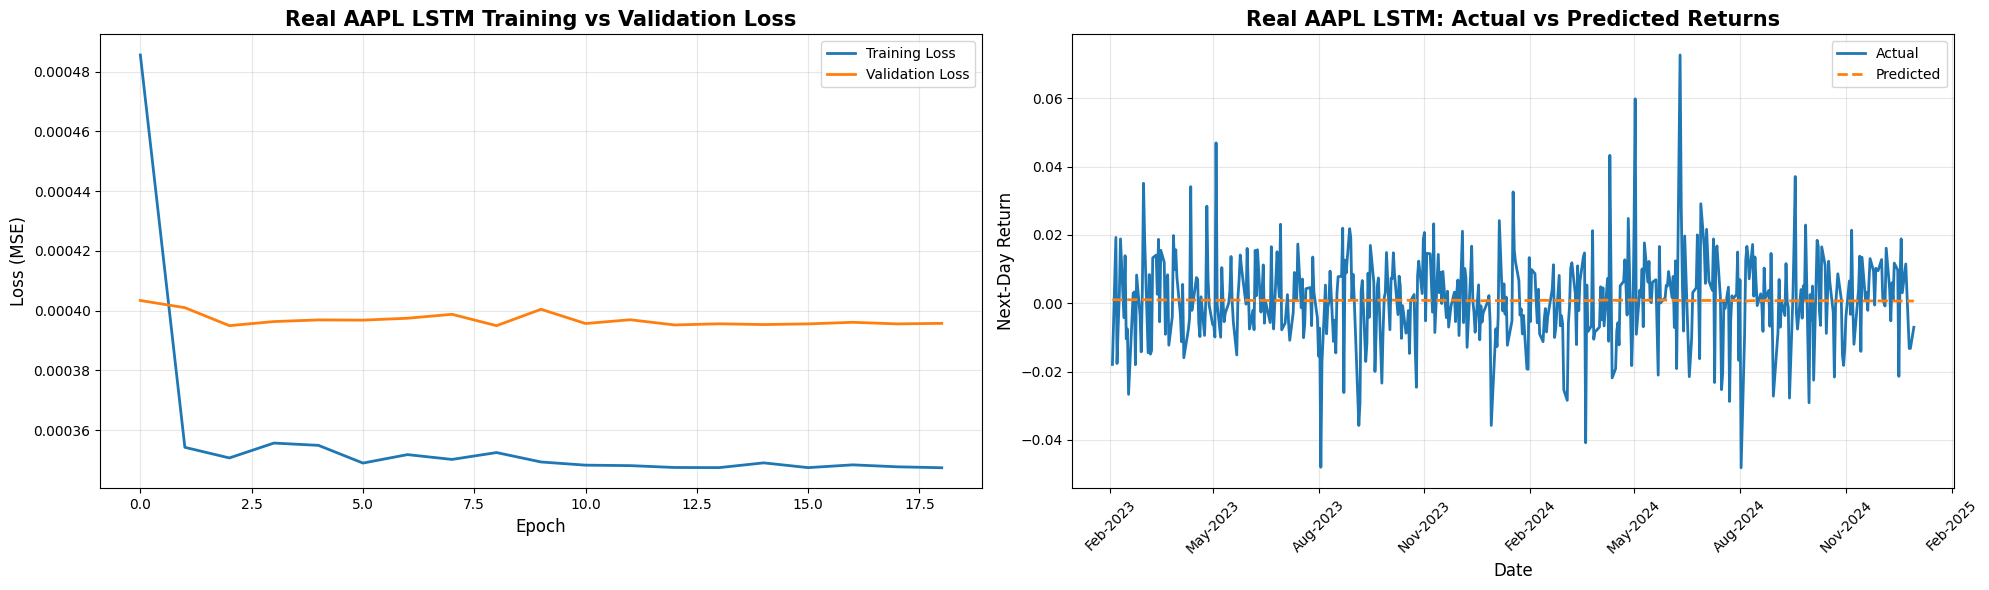

In [11]:
test_dates_real = test_real["Date"].iloc[time_steps_real:].reset_index(drop=True)

fig,axes=plt.subplots(1,2,figsize=(20,6))

axes[0].plot(history_real.history["loss"],label="Training Loss",linewidth=2)
axes[0].plot(history_real.history["val_loss"],label="Validation Loss",linewidth=2)
axes[0].set_title("Real AAPL LSTM Training vs Validation Loss",fontsize=15,fontweight="bold")
axes[0].set_xlabel("Epoch",fontsize=12)
axes[0].set_ylabel("Loss (MSE)",fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(test_dates_real,y_test_lstm_real,label="Actual",linewidth=2)
axes[1].plot(test_dates_real,test_pred_lstm_real,"--",label="Predicted",linewidth=2)
axes[1].set_title("Real AAPL LSTM: Actual vs Predicted Returns",fontsize=15,fontweight="bold")
axes[1].set_xlabel("Date",fontsize=12)
axes[1].set_ylabel("Next-Day Return",fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

for label in axes[1].get_xticklabels():
    label.set_rotation(45)
    
plt.tight_layout()
plt.show()

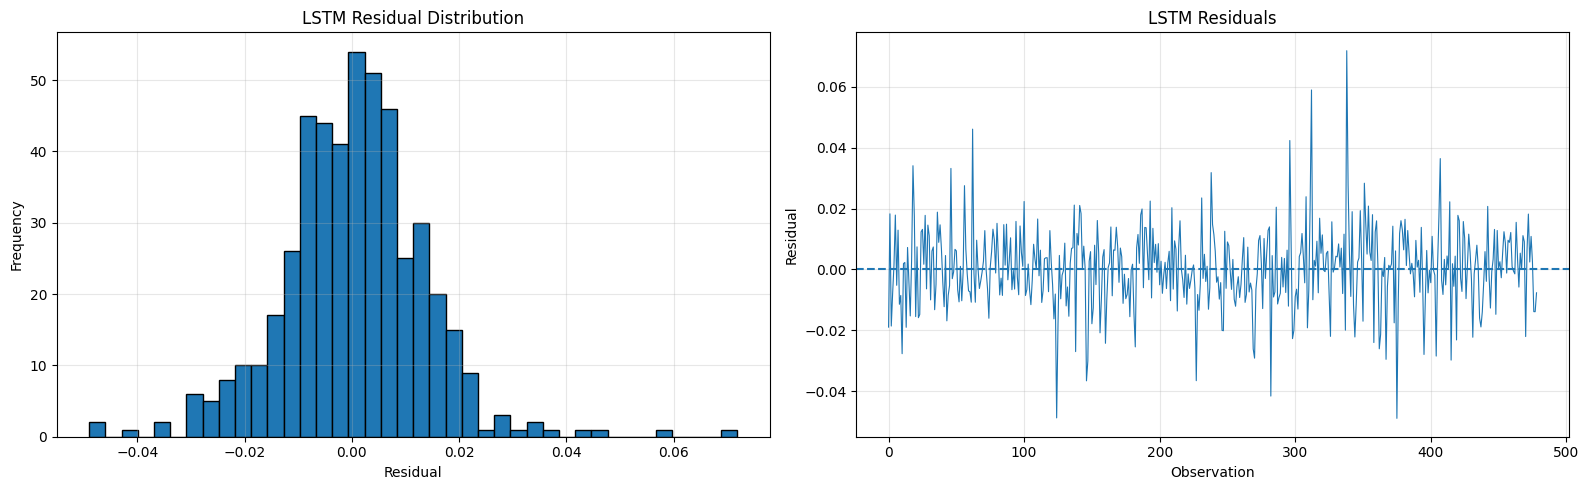

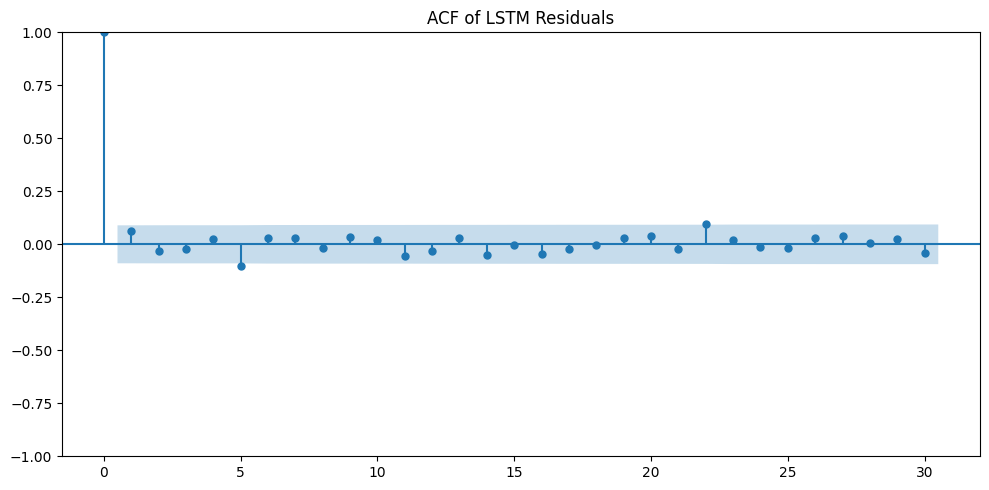

      lb_stat  lb_pvalue
5    7.958494   0.158538
10   9.667218   0.470158
20  15.899307   0.722851


In [12]:
residual_lstm_real=y_test_lstm_real-test_pred_lstm_real

fig,ax=plt.subplots(1,2,figsize=(16,5))

ax[0].hist(
    residual_lstm_real,
    bins=40,
    edgecolor="black"
)
ax[0].set_title("LSTM Residual Distribution")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha=0.3)

ax[1].plot(
    residual_lstm_real,
    linewidth=0.8
)
ax[1].axhline(0,linestyle="--")
ax[1].set_title("LSTM Residuals")
ax[1].set_xlabel("Observation")
ax[1].set_ylabel("Residual")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig,ax=plt.subplots(figsize=(10,5))

plot_acf(
    residual_lstm_real,
    lags=30,
    ax=ax
)

ax.set_title("ACF of LSTM Residuals")
plt.tight_layout()
plt.show()

ljungbox_residual_lstm_real=acorr_ljungbox(
    residual_lstm_real,
    lags=[5,10,20],
    return_df=True
)

print(ljungbox_residual_lstm_real)

# **Comparision Linear Regression model and LSTM**

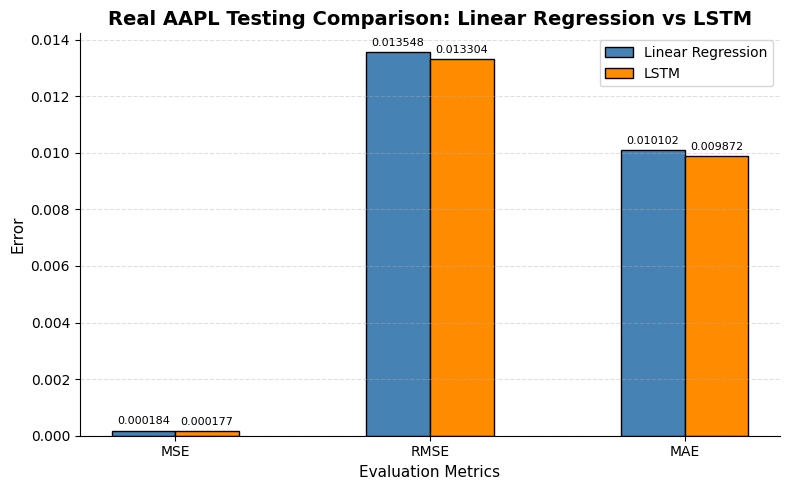

In [13]:
metrics_real = ["MSE","RMSE","MAE"]

lr_real = [test_metrics_real[0],test_metrics_real[1],test_metrics_real[2]]
lstm_real = [test_metrics_lstm_real[0],test_metrics_lstm_real[1],test_metrics_lstm_real[2]]

x_real=np.arange(len(metrics_real))
width_real=0.25
fig,ax=plt.subplots(figsize=(8,5),dpi=100)

bars1=ax.bar(x_real-width_real/2,lr_real,width_real,label="Linear Regression",color="steelblue",edgecolor="black")
bars2=ax.bar(x_real+width_real/2,lstm_real,width_real,label="LSTM",color="darkorange",edgecolor="black")

ax.bar_label(bars1,fmt="%.6f",padding=3,fontsize=8)
ax.bar_label(bars2,fmt="%.6f",padding=3,fontsize=8)
ax.set_title("Real AAPL Testing Comparison: Linear Regression vs LSTM",fontsize=14,fontweight="bold")
ax.set_xlabel("Evaluation Metrics",fontsize=11)
ax.set_ylabel("Error",fontsize=11)
ax.set_xticks(x_real)
ax.set_xticklabels(metrics_real,fontsize=10)
ax.grid(axis="y",linestyle="--",alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10,loc="upper right")

plt.tight_layout()
plt.show()

# **Generating Random Data**

In [14]:
np.random.seed(42)
df_random=pd.DataFrame()
df_random["Date"]= df_real["Date"]
df_random["Return"]= np.random.normal(
    loc=df_real["Return"].mean(),
    scale=df_real["Return"].std(),
    size=len(df_real)
)
print(df_random.head())
df_random["Lag1"]=df_random["Return"].shift(1)
df_random["Lag2"]=df_random["Return"].shift(2)
df_random["Lag5"]=df_random["Return"].shift(5)
df_random["MA5"]=df_random["Return"].rolling(window=5).mean()
df_random["MA20"]=df_random["Return"].rolling(window=20).mean()
df_random["Volatility20"]= df_random["Return"].rolling(window=20).std()

df_random["VolumeChange"]= np.random.normal(
    loc=0,
    scale=1,
    size=len(df_random)
)

df_random["Target"]=df_random["Return"].shift(-1)
df_random=df_random.dropna()
df_random=df_random.reset_index(drop=True)
#print(df_random.head())
#print(df_random.shape)

df_random.to_csv(
    "Random_Return_Dataset.csv",
    index=False
)

features_random=["Lag1","Lag2","Lag5","MA5","MA20","Volatility20","VolumeChange"]

X_random=df_random[features_random]
y_random=df_random["Target"]

split_random=int(len(df_random)*0.80)

X_train_random=X_random.iloc[:split_random].copy()
X_test_random=X_random.iloc[split_random:].copy()

y_train_random=y_random.iloc[:split_random].copy()
y_test_random=y_random.iloc[split_random:].copy()

print()
print("Training observations :",len(X_train_random))
print("Testing observations :",len(X_test_random))

print()
print("Training Start :",df_random["Date"].iloc[0])
print("Training End :",df_random["Date"].iloc[split_random-1])

print()
print("Testing Start :",df_random["Date"].iloc[split_random])
print("Testing End :",df_random["Date"].iloc[-1])

scaler_random=MinMaxScaler()

X_train_random_scaled=scaler_random.fit_transform(X_train_random)
X_test_random_scaled=scaler_random.transform(X_test_random)

X_train_random_scaled=pd.DataFrame(
    X_train_random_scaled,
    columns=features_random,
    index=X_train_random.index
)

X_test_random_scaled=pd.DataFrame(
    X_test_random_scaled,
    columns=features_random,
    index=X_test_random.index
)

X_train_random_scaled.to_csv(
    "X_train_Random_scaled.csv",
    index=False
)

X_test_random_scaled.to_csv(
    "X_test_Random_scaled.csv",
    index=False
)

y_train_random.to_csv(
    "y_train_Random.csv",
    index=False
)

y_test_random.to_csv(
    "y_test_Random.csv",
    index=False
)


        Date    Return
0 2015-02-04  0.009949
1 2015-02-05 -0.001408
2 2015-02-06  0.012649
3 2015-02-09  0.028304
4 2015-02-10 -0.003122

Training observations : 1978
Testing observations : 495

Training Start : 2015-03-04 00:00:00
Training End : 2023-01-09 00:00:00

Testing Start : 2023-01-10 00:00:00
Testing End : 2024-12-27 00:00:00


# **Linear Regression On Random Data**

In [15]:
X_train_random=pd.read_csv("X_train_Random_scaled.csv")
X_test_random=pd.read_csv("X_test_Random_scaled.csv")

y_train_random=pd.read_csv("y_train_Random.csv").squeeze()
y_test_random=pd.read_csv("y_test_Random.csv").squeeze()

lr_random=LinearRegression()

lr_random.fit(
    X_train_random,
    y_train_random
)

train_pred_random=lr_random.predict(X_train_random)
test_pred_random=lr_random.predict(X_test_random)

def evaluate_model_random(actual,predicted):
    mse=mean_squared_error(actual,predicted)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(actual,predicted)
    r2=r2_score(actual,predicted)
    return mse,rmse,mae,r2

train_metrics_random=evaluate_model_random(
    y_train_random,
    train_pred_random
)

test_metrics_random=evaluate_model_random(
    y_test_random,
    test_pred_random
)

results_random=pd.DataFrame({
    "Dataset":[
        "Training",
        "Testing"
    ],
    "MSE":[
        train_metrics_random[0],
        test_metrics_random[0]
    ],
    "RMSE":[
        train_metrics_random[1],
        test_metrics_random[1]
    ],
    "MAE":[
        train_metrics_random[2],
        test_metrics_random[2]
    ],
    "R2":[
        train_metrics_random[3],
        test_metrics_random[3]
    ]
})

print(results_random)

results_random.to_csv(
    "Random_LinearRegression_Results.csv",
    index=False
)

    Dataset       MSE      RMSE       MAE        R2
0  Training  0.000312  0.017667  0.014016  0.001944
1   Testing  0.000296  0.017205  0.013821 -0.007362


Training MSE : 0.000312
Testing MSE  : 0.000296
Random Overfitting Gap : -1.6e-05

Linear Regression Coefficients
        Feature  Coefficient
0          Lag1     0.000826
1          Lag2     0.004522
2          Lag5    -0.000990
3           MA5    -0.003045
4          MA20    -0.000893
5  Volatility20    -0.000392
6  VolumeChange     0.003222
Mean Residual : -0.001224
Std Residual : 0.017179
Minimum Residual : -0.055389
Maximum Residual : 0.056236


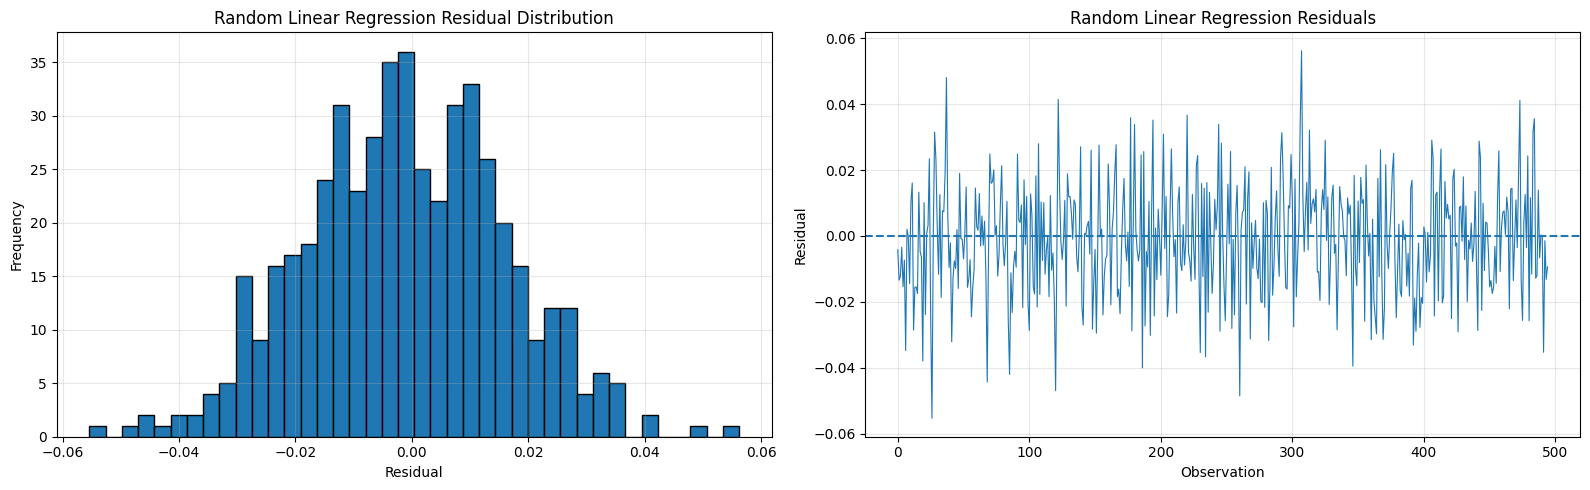

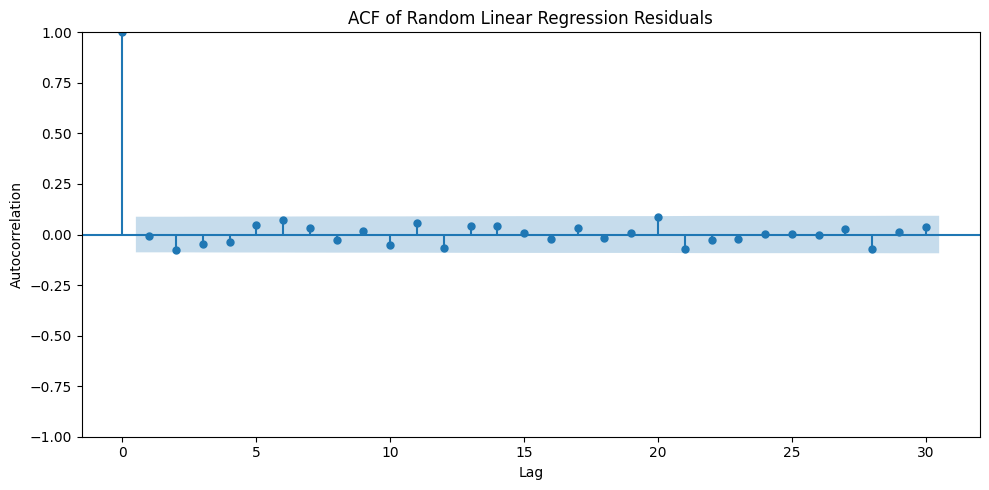

Ljung-Box Test: Random Linear Regression Residuals
      lb_stat  lb_pvalue
5    5.819846   0.324145
10  10.769133   0.375785
20  21.187630   0.386164
     Actual  Predicted  Residual
0 -0.001851   0.002357 -0.004208
1 -0.012257   0.001167 -0.013424
2 -0.011010   0.001185 -0.012195
3 -0.001519   0.001896 -0.003415
4 -0.013107   0.002311 -0.015418
Random Linear Regression Directional Accuracy : 51.52 %


In [16]:
gap_random=test_metrics_random[0]-train_metrics_random[0]
print("Training MSE :",round(train_metrics_random[0],6))
print("Testing MSE  :",round(test_metrics_random[0],6))
print("Random Overfitting Gap :",round(gap_random,6))

coef_random=pd.DataFrame({
    "Feature":X_train_random.columns,
    "Coefficient":lr_random.coef_
})

print()
print("Linear Regression Coefficients")
print(coef_random)

coef_random.to_csv(
    "RandomDataset_Coefficients.csv",
    index=False
)

residual_lr_random=y_test_random-test_pred_random

print("Mean Residual :",round(residual_lr_random.mean(),6))
print("Std Residual :",round(residual_lr_random.std(),6))
print("Minimum Residual :",round(residual_lr_random.min(),6))
print("Maximum Residual :",round(residual_lr_random.max(),6))

fig,ax=plt.subplots(1,2,figsize=(16,5))

ax[0].hist(
    residual_lr_random,
    bins=40,
    edgecolor="black"
)
ax[0].set_title("Random Linear Regression Residual Distribution")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha=0.3)

ax[1].plot(
    residual_lr_random,
    linewidth=0.8
)
ax[1].axhline(0,linestyle="--")
ax[1].set_title("Random Linear Regression Residuals")
ax[1].set_xlabel("Observation")
ax[1].set_ylabel("Residual")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig,ax=plt.subplots(figsize=(10,5))

plot_acf(
    residual_lr_random,
    lags=30,
    ax=ax
)

ax.set_title("ACF of Random Linear Regression Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

ljungbox_residual_lr_random=acorr_ljungbox(
    residual_lr_random,
    lags=[5,10,20],
    return_df=True
)

print("Ljung-Box Test: Random Linear Regression Residuals")
print(ljungbox_residual_lr_random)

prediction_lr_random=pd.DataFrame({
    "Actual":y_test_random,
    "Predicted":test_pred_random,
    "Residual":y_test_random-test_pred_random
})

prediction_lr_random.to_csv(
    "Random_LinearRegression_Predictions.csv",
    index=False
)

print(prediction_lr_random.head())


actual_direction_random = np.sign(
    y_test_random.values
)

predicted_direction_random = np.sign(
    test_pred_random
)

direction_lr_random = np.mean(
    actual_direction_random == predicted_direction_random
)

print(
    "Random Linear Regression Directional Accuracy :",
    round(direction_lr_random * 100, 2),
    "%"
)

In [17]:
X_train_random=pd.read_csv("X_train_Random_scaled.csv")
X_test_random=pd.read_csv("X_test_Random_scaled.csv")

y_train_random=pd.read_csv("y_train_Random.csv").squeeze()
y_test_random=pd.read_csv("y_test_Random.csv").squeeze()

time_steps_random=20

def create_sequences_random(X,y,time_steps):
    X_seq_random=[]
    y_seq_random=[]
    for i in range(len(X)-time_steps):
        X_seq_random.append(X.iloc[i:i+time_steps].values)
        y_seq_random.append(y.iloc[i+time_steps])
    return np.array(X_seq_random),np.array(y_seq_random)

X_train_seq_random,y_train_seq_random=create_sequences_random(
    X_train_random,
    y_train_random,
    time_steps_random
)

X_test_seq_random,y_test_seq_random=create_sequences_random(
    X_test_random,
    y_test_random,
    time_steps_random
)

print("Training Shape :",X_train_seq_random.shape)
print("Training Target Shape :",y_train_seq_random.shape)
print("Testing Shape :",X_test_seq_random.shape)
print("Testing Target Shape :",y_test_seq_random.shape)

np.save("X_train_seq_random.npy",X_train_seq_random)
np.save("X_test_seq_random.npy",X_test_seq_random)
np.save("y_train_seq_random.npy",y_train_seq_random)
np.save("y_test_seq_random.npy",y_test_seq_random)

lstm_random=Sequential([
    LSTM(64,return_sequences=True,input_shape=(time_steps_random,X_train_seq_random.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16,activation="relu"),
    Dense(1)
])

lstm_random.summary()

lstm_random.compile(
    optimizer="adam",
    loss="mse"
)

early_stop_random=EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_random=lstm_random.fit(
    X_train_seq_random,
    y_train_seq_random,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_random],
    verbose=1
)

lstm_random.save("LSTM_Random_Model.keras")

history_random_df=pd.DataFrame(history_random.history)
history_random_df.to_csv(
    "LSTM_Random_History.csv",
    index=False
)

print("Training Loss :",history_random.history["loss"][-1])
print("Validation Loss :",history_random.history["val_loss"][-1])

train_pred_lstm_random=lstm_random.predict(
    X_train_seq_random
).flatten()

test_pred_lstm_random=lstm_random.predict(
    X_test_seq_random
).flatten()

def evaluate_lstm_random(actual,pred):
    mse=mean_squared_error(actual,pred)
    rmse=np.sqrt(mse)
    mae=mean_absolute_error(actual,pred)
    r2=r2_score(actual,pred)
    return mse,rmse,mae,r2

train_metrics_lstm_random=evaluate_lstm_random(
    y_train_seq_random,
    train_pred_lstm_random
)

test_metrics_lstm_random=evaluate_lstm_random(
    y_test_seq_random,
    test_pred_lstm_random
)

results_lstm_random=pd.DataFrame({
    "Dataset":["Training","Testing"],
    "MSE":[
        train_metrics_lstm_random[0],
        test_metrics_lstm_random[0]
    ],
    "RMSE":[
        train_metrics_lstm_random[1],
        test_metrics_lstm_random[1]
    ],
    "MAE":[
        train_metrics_lstm_random[2],
        test_metrics_lstm_random[2]
    ],
    "R2":[
        train_metrics_lstm_random[3],
        test_metrics_lstm_random[3]
    ]
})

print(results_lstm_random)

results_lstm_random.to_csv(
    "LSTM_Random_Results.csv",
    index=False
)

Training Shape : (1958, 20, 7)
Training Target Shape : (1958,)
Testing Shape : (475, 20, 7)
Testing Target Shape : (475,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0012 - val_loss: 3.4806e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.6083e-04 - val_loss: 3.0404e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.2911e-04 - val_loss: 3.0207e-04
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2079e-04 - val_loss: 3.0118e-04
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2302e-04 - val_loss: 3.0121e-04
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2290e-04 - val_loss: 3.0124e-04
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.1881e-04 - val_loss: 3.0136e-04
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.1756e-04 - val_loss: 3.0126e-04
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.1670e-04 - val_loss: 3.0128e-04
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.1889e-04 - val_loss: 3.0128e-04
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.


Training MSE : 0.000313
Testing MSE : 0.000297
Overfitting Gap : -1.6e-05
     Actual  Predicted  Residual
0  0.012429   0.002423  0.010007
1 -0.021098   0.002423 -0.023521
2  0.002137   0.002423 -0.000286
3  0.006026   0.002423  0.003603
4  0.025400   0.002423  0.022977
Random LSTM Directional Accuracy : 52.84 %


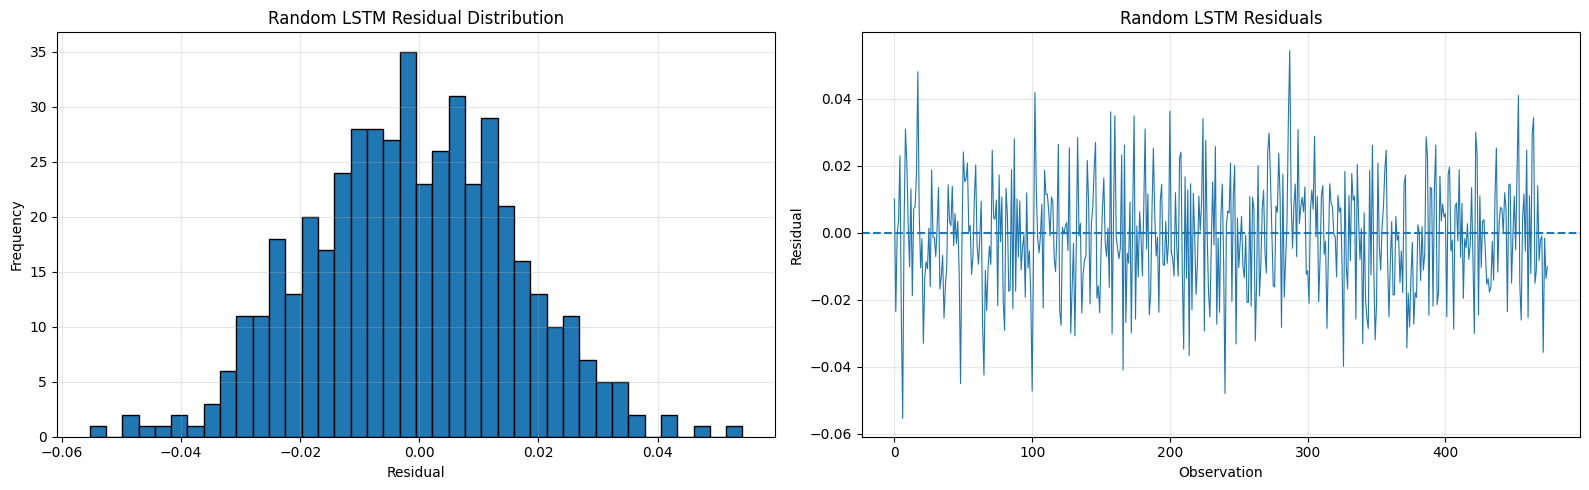

      lb_stat  lb_pvalue
5    6.800821   0.235880
10   9.350686   0.499177
20  18.749033   0.538189


In [18]:
gap_lstm_random=(
    test_metrics_lstm_random[0]
    -train_metrics_lstm_random[0]
)

print()
print("Training MSE :",round(train_metrics_lstm_random[0],6))
print("Testing MSE :",round(test_metrics_lstm_random[0],6))
print("Overfitting Gap :",round(gap_lstm_random,6))

prediction_lstm_random=pd.DataFrame({
    "Actual":y_test_seq_random,
    "Predicted":test_pred_lstm_random,
    "Residual":y_test_seq_random-test_pred_lstm_random
})

prediction_lstm_random.to_csv(
    "LSTM_Random_Predictions.csv",
    index=False
)

print(prediction_lstm_random.head())

direction_lstm_random=directional_accuracy(
    y_test_seq_random,
    test_pred_lstm_random
)

print(
    "Random LSTM Directional Accuracy :",
    round(direction_lstm_random*100,2),
    "%"
)

residual_lstm_random=y_test_seq_random-test_pred_lstm_random

fig,ax=plt.subplots(1,2,figsize=(16,5))

ax[0].hist(
    residual_lstm_random,
    bins=40,
    edgecolor="black"
)
ax[0].set_title("Random LSTM Residual Distribution")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha=0.3)

ax[1].plot(
    residual_lstm_random,
    linewidth=0.8
)
ax[1].axhline(0,linestyle="--")
ax[1].set_title("Random LSTM Residuals")
ax[1].set_xlabel("Observation")
ax[1].set_ylabel("Residual")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ljungbox_residual_lstm_random=acorr_ljungbox(
    residual_lstm_random,
    lags=[5,10,20],
    return_df=True
)

print(ljungbox_residual_lstm_random)

direction_lr_random=directional_accuracy(
    y_test_random,
    test_pred_random
)

                      Model       MSE      RMSE       MAE        R2  \
0         Naive Mean Return  0.000181  0.013460  0.010005 -0.001710   
1    Real Linear Regression  0.000184  0.013548  0.010102 -0.014770   
2                 Real LSTM  0.000177  0.013304  0.009872 -0.000139   
3  Random Linear Regression  0.000296  0.017205  0.013821 -0.007362   
4               Random LSTM  0.000297  0.017225  0.013861 -0.005902   

   Directional Accuracy  
0              0.563126  
1              0.498998  
2              0.553236  
3              0.515152  
4              0.528421  


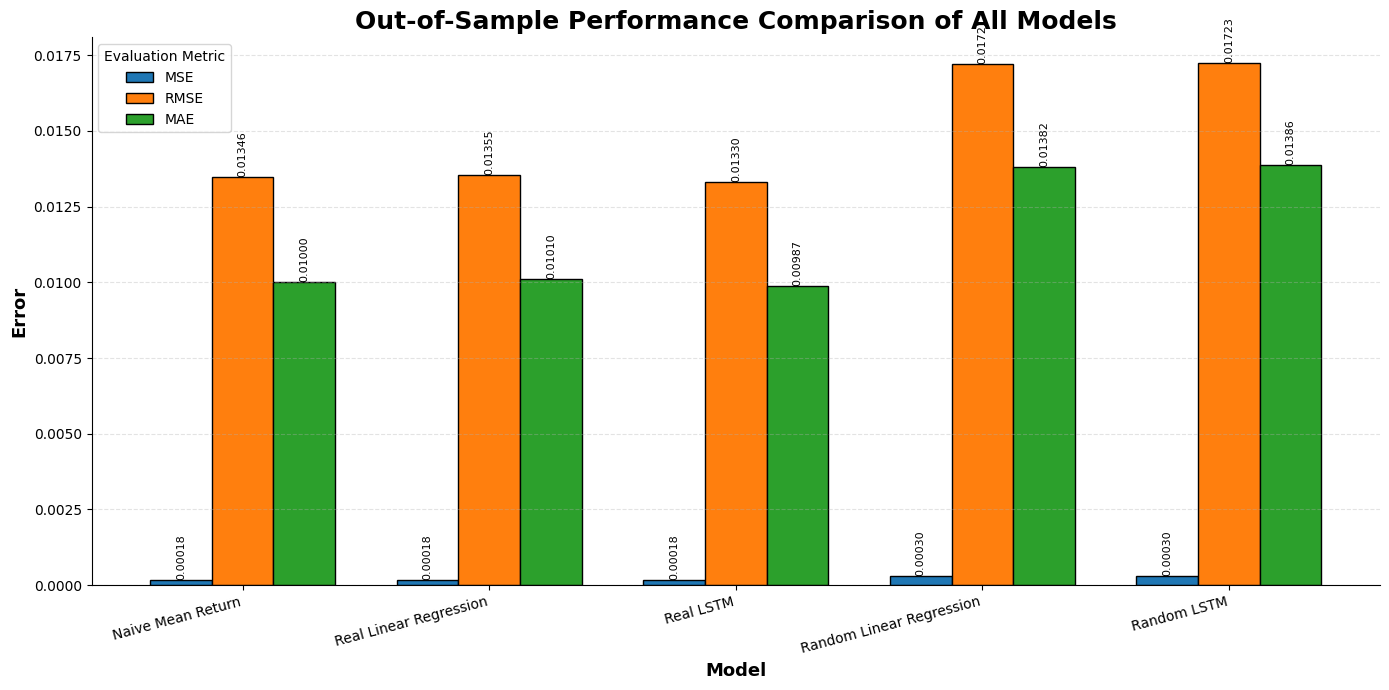

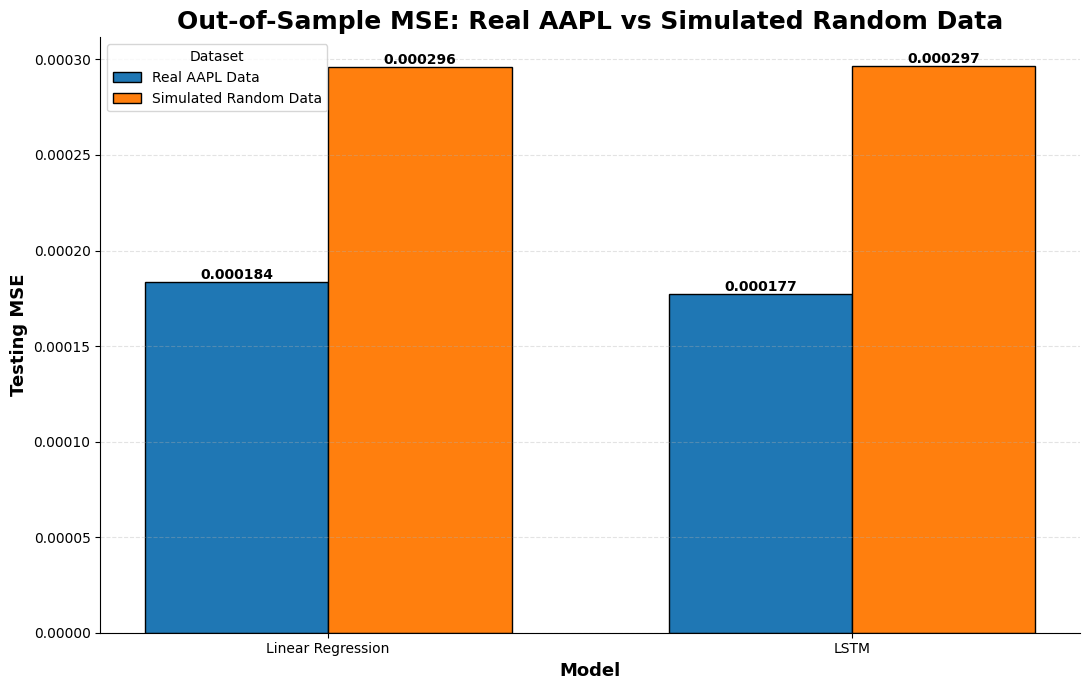

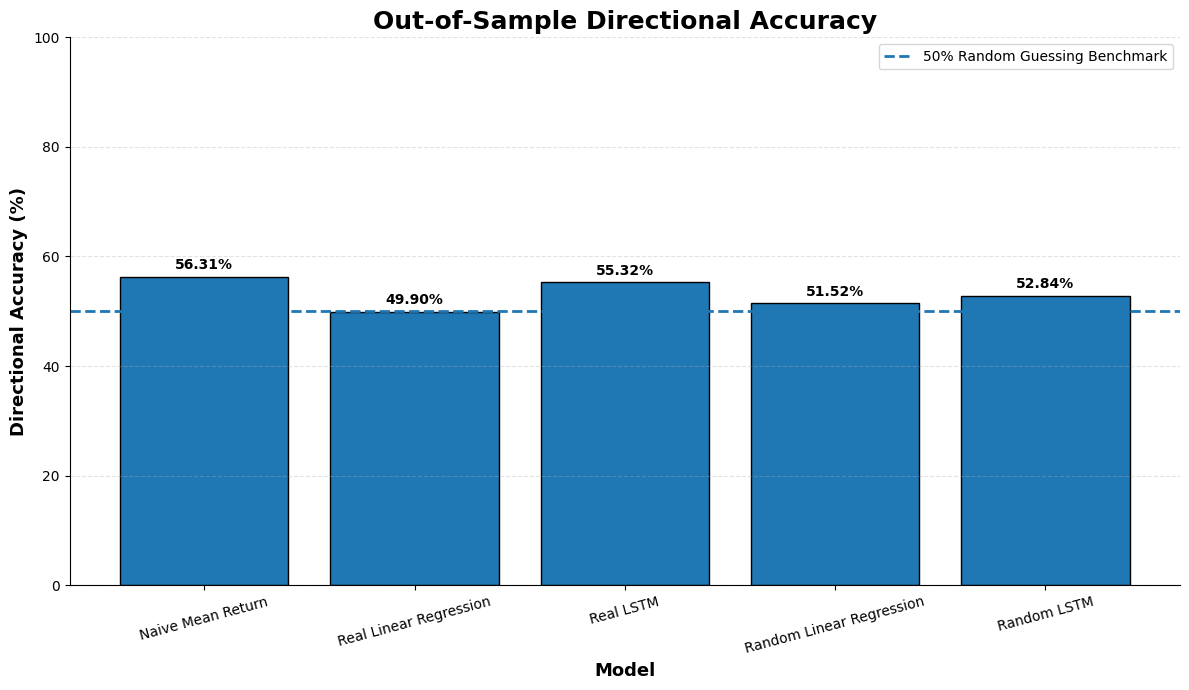

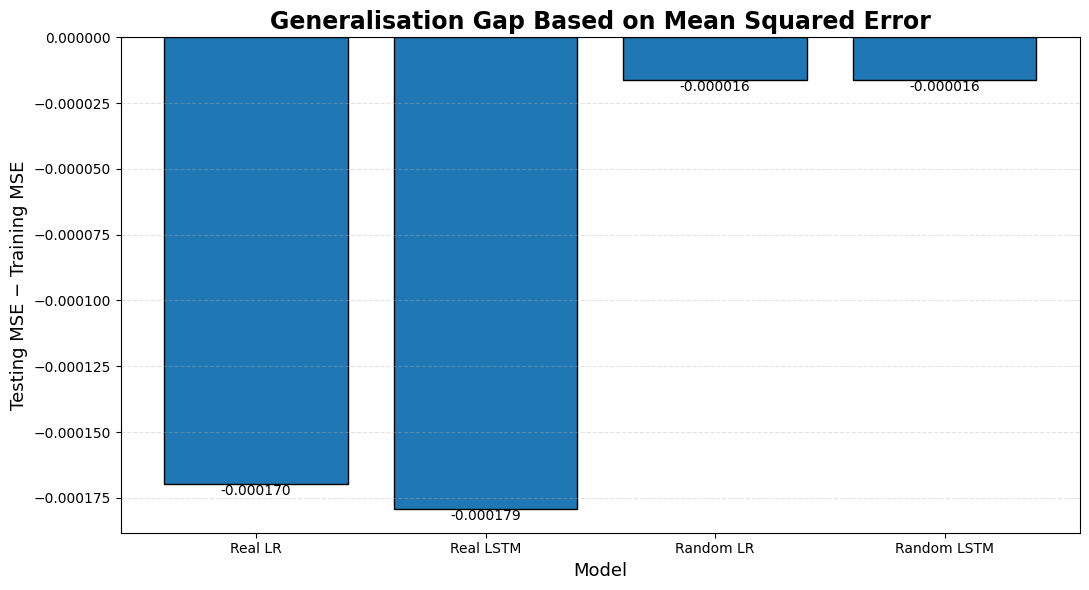


Linear Regression errors : 479
LSTM errors : 479

Paired t-test
t-statistic : 1.9338
p-value : 0.053733

Wilcoxon Signed-Rank Test
Statistic : 52242.0
p-value : 0.083967

Paired Effect Size : 0.0884


In [19]:
lr_real_results=pd.read_csv("LinearRegression_Real_Results.csv")
lstm_real_results=pd.read_csv("LSTM_Real_Results.csv")
lr_random_results=pd.read_csv("Random_LinearRegression_Results.csv")
lstm_random_results=pd.read_csv("LSTM_Random_Results.csv")

lr_real_pred=pd.read_csv("LinearRegression_Real_Predictions.csv")
lstm_real_pred=pd.read_csv("LSTM_Real_Predictions.csv")
lr_random_pred=pd.read_csv("Random_LinearRegression_Predictions.csv")
lstm_random_pred=pd.read_csv("LSTM_Random_Predictions.csv")

direction_lr_real=directional_accuracy(
    y_test_real,
    test_pred_real
)

direction_lstm_real=directional_accuracy(
    y_test_lstm_real,
    test_pred_lstm_real
)

direction_lr_random=directional_accuracy(
    y_test_random,
    test_pred_random
)

direction_lstm_random=directional_accuracy(
    y_test_seq_random,
    test_pred_lstm_random
)

comparison_final=pd.DataFrame({
    "Model":[
        "Naive Mean Return",
        "Real Linear Regression",
        "Real LSTM",
        "Random Linear Regression",
        "Random LSTM"
    ],
    "MSE":[
        naive_metrics_real[0],
        lr_real_results.loc[1,"MSE"],
        lstm_real_results.loc[1,"MSE"],
        lr_random_results.loc[1,"MSE"],
        lstm_random_results.loc[1,"MSE"]
    ],
    "RMSE":[
        naive_metrics_real[1],
        lr_real_results.loc[1,"RMSE"],
        lstm_real_results.loc[1,"RMSE"],
        lr_random_results.loc[1,"RMSE"],
        lstm_random_results.loc[1,"RMSE"]
    ],
    "MAE":[
        naive_metrics_real[2],
        lr_real_results.loc[1,"MAE"],
        lstm_real_results.loc[1,"MAE"],
        lr_random_results.loc[1,"MAE"],
        lstm_random_results.loc[1,"MAE"]
    ],
    "R2":[
        naive_metrics_real[3],
        lr_real_results.loc[1,"R2"],
        lstm_real_results.loc[1,"R2"],
        lr_random_results.loc[1,"R2"],
        lstm_random_results.loc[1,"R2"]
    ],
    "Directional Accuracy":[
        direction_naive_real,
        direction_lr_real,
        direction_lstm_real,
        direction_lr_random,
        direction_lstm_random
    ]
})

print(comparison_final)

comparison_final.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

models_final=[
    "Naive Mean Return",
    "Real Linear Regression",
    "Real LSTM",
    "Random Linear Regression",
    "Random LSTM"]

metrics=["MSE","RMSE","MAE"]
x=np.arange(len(models_final))
width=0.25

fig,ax=plt.subplots(figsize=(14,7))
bars_mse=ax.bar(x-width,comparison_final["MSE"],width,label="MSE",edgecolor="black")
bars_rmse=ax.bar(x,comparison_final["RMSE"],width,label="RMSE",edgecolor="black")
bars_mae=ax.bar(x+width,comparison_final["MAE"],width,label="MAE",edgecolor="black")

for bars in [bars_mse,bars_rmse,bars_mae]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f"{bar.get_height():.5f}",ha="center",va="bottom",fontsize=8,rotation=90)

ax.set_title("Out-of-Sample Performance Comparison of All Models",fontsize=18,fontweight="bold")
ax.set_xlabel("Model",fontsize=13,fontweight="bold")
ax.set_ylabel("Error",fontsize=13,fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models_final,rotation=15,ha="right")
ax.legend(title="Evaluation Metric")
ax.grid(axis="y",linestyle="--",alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

models_compare=["Linear Regression","LSTM"]

real_mse=[comparison_final.loc[comparison_final["Model"]=="Real Linear Regression","MSE"].iloc[0],
          comparison_final.loc[comparison_final["Model"]=="Real LSTM","MSE"].iloc[0]]

random_mse=[comparison_final.loc[comparison_final["Model"]=="Random Linear Regression","MSE"].iloc[0],
            comparison_final.loc[comparison_final["Model"]=="Random LSTM","MSE"].iloc[0]]

x=np.arange(len(models_compare))
width=0.35

fig,ax=plt.subplots(figsize=(11,7))
bars_real=ax.bar(x-width/2,real_mse,width,label="Real AAPL Data",edgecolor="black")
bars_random=ax.bar(x+width/2,random_mse,width,label="Simulated Random Data",edgecolor="black")

for bars in [bars_real,bars_random]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f"{bar.get_height():.6f}",ha="center",va="bottom",fontsize=10,fontweight="bold")

ax.set_title("Out-of-Sample MSE: Real AAPL vs Simulated Random Data",fontsize=18,fontweight="bold")
ax.set_xlabel("Model",fontsize=13,fontweight="bold")
ax.set_ylabel("Testing MSE",fontsize=13,fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models_compare)
ax.legend(title="Dataset")
ax.grid(axis="y",linestyle="--",alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

directional_values=comparison_final["Directional Accuracy"]*100

fig,ax=plt.subplots(figsize=(12,7))
bars=ax.bar(models_final,directional_values,edgecolor="black")
ax.axhline(50,linestyle="--",linewidth=2,label="50% Random Guessing Benchmark")

for bar,value in zip(bars,directional_values):
    ax.text(bar.get_x()+bar.get_width()/2,value+0.8,f"{value:.2f}%",ha="center",va="bottom",fontsize=10,fontweight="bold")

ax.set_title("Out-of-Sample Directional Accuracy",fontsize=18,fontweight="bold")
ax.set_xlabel("Model",fontsize=13,fontweight="bold")
ax.set_ylabel("Directional Accuracy (%)",fontsize=13,fontweight="bold")
ax.set_ylim(0,max(100,directional_values.max()+10))
ax.tick_params(axis="x",rotation=15)
ax.grid(axis="y",linestyle="--",alpha=0.35)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

gap_real_lr=lr_real_results.loc[1,"MSE"]-lr_real_results.loc[0,"MSE"]
gap_real_lstm=lstm_real_results.loc[1,"MSE"]-lstm_real_results.loc[0,"MSE"]
gap_random_lr=lr_random_results.loc[1,"MSE"]-lr_random_results.loc[0,"MSE"]
gap_random_lstm=lstm_random_results.loc[1,"MSE"]-lstm_random_results.loc[0,"MSE"]

gap_values=[gap_real_lr,gap_real_lstm,gap_random_lr,gap_random_lstm]
gap_models=["Real LR","Real LSTM","Random LR","Random LSTM"]

fig,ax=plt.subplots(figsize=(11,6))
bars=ax.bar(gap_models,gap_values,edgecolor="black")
ax.axhline(0,linestyle="--",linewidth=1.5)

for bar,value in zip(bars,gap_values):
    ax.text(bar.get_x()+bar.get_width()/2,value,f"{value:.6f}",
            ha="center",va="bottom" if value>=0 else "top",fontsize=10)

ax.set_title("Generalisation Gap Based on Mean Squared Error",fontsize=17,fontweight="bold")
ax.set_xlabel("Model",fontsize=13)
ax.set_ylabel("Testing MSE − Training MSE",fontsize=13)
ax.grid(axis="y",linestyle="--",alpha=0.35)
plt.tight_layout()
plt.show()

lr_error_real=np.abs(
    lr_real_pred["Residual"].values[-len(lstm_real_pred):]
)

lstm_error_real=np.abs(
    lstm_real_pred["Residual"].values
)

print()
print("Linear Regression errors :",len(lr_error_real))
print("LSTM errors :",len(lstm_error_real))

t_real,p_real=ttest_rel(
    lr_error_real,
    lstm_error_real
)

print()
print("Paired t-test")
print("t-statistic :",round(t_real,4))
print("p-value :",round(p_real,6))

w_real,p_wilcoxon_real=wilcoxon(
    lr_error_real,
    lstm_error_real
)

print()
print("Wilcoxon Signed-Rank Test")
print("Statistic :",round(w_real,4))
print("p-value :",round(p_wilcoxon_real,6))

effect_size_real=(
    np.mean(lr_error_real-lstm_error_real)
    /np.std(lr_error_real-lstm_error_real,ddof=1)
)

print()
print("Paired Effect Size :",round(effect_size_real,4))